# Librerías

In [1]:
# Sistema
import os
import sys
import json
import random
from pathlib import Path

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import plotly
import plotly.express as px
import plotly.graph_objects as go

# Interactividad en notebook
import ipywidgets as widgets
from IPython.display import display, clear_output

# Preprocesamiento y modelado clásico
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model

# Persistencia de objetos
import joblib

# Configuración pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Revisión de versiones
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("plotly:", plotly.__version__)
print("ipywidgets:", widgets.__version__)
print("tensorflow:", tf.__version__)

I0000 00:00:1779415367.372277   23990 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779415368.406426   23990 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779415373.200120   23990 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
pandas: 2.3.3
numpy: 2.2.6
plotly: 6.6.0
ipywidgets: 8.1.8
tensorflow: 2.21.0


In [2]:
SEED = 176

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Semilla global definida: {SEED}")

Semilla global definida: 176


In [46]:
percentiles = np.concatenate([
    np.arange(0.00, 0.06, step=0.01),
    np.arange(0.10, 0.90, step=0.10),
    np.arange(0.95, 1.00, step=0.01)
])

# Lectura

In [3]:
data_path = Path("data")

for file in data_path.glob("*.csv"):
    print(file.name)

train_default.csv
train_PAY_AMT1.csv
val_PAY_AMT1.csv
val_default.csv


In [4]:
train_pay = pd.read_csv(data_path / "train_PAY_AMT1.csv", delimiter='|')
val_pay = pd.read_csv(data_path / "val_PAY_AMT1.csv", delimiter='|')

train_default = pd.read_csv(data_path / "train_default.csv", delimiter='|')
val_default = pd.read_csv(data_path / "val_default.csv", delimiter='|')

In [5]:
print(train_pay.shape)
print(val_pay.shape)
print(train_pay.columns, end='\n\n')

print(train_default.shape)
print(val_default.shape)
print(train_default.columns)

(11250, 23)
(3750, 22)
Index(['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

(5625, 25)
(1875, 24)
Index(['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
       'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


# Clases / Funciones Auxiliares

## EDA

In [49]:
class eda_class:
    """
    Clase para análisis exploratorio visual usando Plotly.

    Permite analizar variables continuas, discretas y relaciones entre variables,
    tomando como base un dataframe principal y un dataframe resumen de campos
    con la columna 'clasificacion'.
    """

    def __init__(
        self,
        df,
        resumen_campos,
        target=None,
        id_col=None,
        output_dir="img"
    ):
        self.df = df.copy()
        self.resumen_campos = resumen_campos.copy()
        self.target = target
        self.id_col = id_col
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self._validar_resumen_campos()

    def _validar_resumen_campos(self):
        """
        Valida que el dataframe resumen tenga las columnas mínimas necesarias.
        """

        columnas_requeridas = {"campo", "clasificacion"}

        columnas_faltantes = columnas_requeridas - set(self.resumen_campos.columns)

        if columnas_faltantes:
            raise ValueError(
                f"Faltan columnas en resumen_campos: {columnas_faltantes}"
            )

    def obtener_columnas(self, clasificacion):
        """
        Obtiene columnas según su clasificación: id, target, continua o discreta.
        """

        columnas = (
            self.resumen_campos
            .loc[self.resumen_campos["clasificacion"] == clasificacion, "campo"]
            .tolist()
        )

        columnas = [col for col in columnas if col in self.df.columns]

        return columnas

    def resumen_continuas(self):
        """
        Genera resumen estadístico para variables continuas.
        """

        continuas = self.obtener_columnas("continua")

        if len(continuas) == 0:
            print("No se encontraron variables continuas.")
            return pd.DataFrame()

        resumen = self.df[continuas].describe(
            percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
        ).T

        return resumen

    def resumen_categoricas(self):
        """
        Genera una tabla de frecuencia y porcentaje para variables discretas.
        """

        discretas = self.obtener_columnas("discreta")

        if len(discretas) == 0:
            print("No se encontraron variables discretas.")
            return pd.DataFrame()

        tablas = []

        for col in discretas:
            tmp = (
                self.df[col]
                .value_counts(dropna=False)
                .reset_index()
            )

            tmp.columns = ["categoria", "frecuencia"]
            tmp["variable"] = col
            tmp["porcentaje"] = tmp["frecuencia"] / len(self.df) * 100
            tmp["porcentaje"] = tmp["porcentaje"].round(2)

            tmp = tmp[["variable", "categoria", "frecuencia", "porcentaje"]]
            tablas.append(tmp)

        return pd.concat(tablas, ignore_index=True)

    def tabla_percentiles(self, col):
        """
        Genera tabla de percentiles para una variable continua.
        """

        self._validar_columna(col)

        percentiles = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]

        tabla = (
            self.df[col]
            .quantile(percentiles)
            .reset_index()
        )

        tabla.columns = ["percentil", "valor"]
        tabla["percentil"] = (tabla["percentil"] * 100).round(0).astype(int)

        return tabla

    def plot_histograma(self, col, bins=50):
        """
        Genera histograma para una variable continua.
        """

        self._validar_columna(col)

        fig = px.histogram(
            self.df,
            x=col,
            nbins=bins,
            title=f"Histograma de {col}",
            marginal="box"
        )

        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Frecuencia",
            template="plotly_white"
        )

        return fig

    def plot_histograma_log(self, col, bins=50):
        """
        Genera histograma con transformación log1p para una variable continua.
        """

        self._validar_columna(col)

        df_tmp = self.df[[col]].copy()
        df_tmp[f"log1p_{col}"] = np.log1p(df_tmp[col].clip(lower=0))

        fig = px.histogram(
            df_tmp,
            x=f"log1p_{col}",
            nbins=bins,
            title=f"Histograma log1p de {col}",
            marginal="box"
        )

        fig.update_layout(
            xaxis_title=f"log1p({col})",
            yaxis_title="Frecuencia",
            template="plotly_white"
        )

        return fig

    def plot_histograma_porcentaje(self, col, bins=50):
        """
        Genera histograma con eje Y expresado en porcentaje.
        No transforma la variable.
        """
    
        self._validar_columna(col)
    
        fig = px.histogram(
            self.df,
            x=col,
            nbins=bins,
            histnorm="percent",
            title=f"Histograma porcentual de {col}",
            marginal="box"
        )
    
        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Porcentaje",
            template="plotly_white"
        )
    
        return fig

    def plot_histograma_normalizado(self, col, bins=50):
        """
        Genera histograma de una variable continua normalizada mediante z-score.
    
        Normalización:
            z = (x - media) / desviación estándar
        """
    
        self._validar_columna(col)
    
        df_tmp = self.df[[col]].copy()
    
        media = df_tmp[col].mean()
        desviacion = df_tmp[col].std()
    
        if desviacion == 0:
            raise ValueError(f"La columna '{col}' tiene desviación estándar cero y no puede normalizarse.")
    
        col_norm = f"{col}_normalizado"
    
        df_tmp[col_norm] = (df_tmp[col] - media) / desviacion
    
        fig = px.histogram(
            df_tmp,
            x=col_norm,
            nbins=bins,
            title=f"Histograma normalizado de {col}",
            marginal="box"
        )
    
        fig.update_layout(
            xaxis_title=f"{col} normalizado: (x - media) / desviación estándar",
            yaxis_title="Frecuencia",
            template="plotly_white"
        )
    
        return fig

    def plot_boxplot(self, col):
        """
        Genera boxplot para una variable continua.
        """

        self._validar_columna(col)

        fig = px.box(
            self.df,
            y=col,
            points="outliers",
            title=f"Boxplot de {col}"
        )

        fig.update_layout(
            yaxis_title=col,
            template="plotly_white"
        )

        return fig

    def plot_barras_cat_pct(self, col):
        """
        Genera gráfico de barras porcentual para una variable discreta.
        """

        self._validar_columna(col)

        tabla = (
            self.df[col]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
            .reset_index()
        )

        tabla.columns = [col, "porcentaje"]
        tabla["porcentaje"] = tabla["porcentaje"].round(2)
        tabla[col] = tabla[col].astype(str)

        fig = px.bar(
            tabla,
            x=col,
            y="porcentaje",
            text="porcentaje",
            title=f"Distribución porcentual de {col}"
        )

        fig.update_traces(
            texttemplate="%{text:.2f}%",
            textposition="outside"
        )

        fig.update_layout(
            xaxis_title=col,
            yaxis_title="Porcentaje",
            template="plotly_white"
        )

        return fig

    def plot_scatter(self, x_col, y_col):
        """
        Genera gráfico de dispersión entre dos variables continuas.
        """

        self._validar_columna(x_col)
        self._validar_columna(y_col)

        fig = px.scatter(
            self.df,
            x=x_col,
            y=y_col,
            title=f"Dispersión: {x_col} vs {y_col}",
            opacity=0.7,
            trendline="ols"
        )

        fig.update_layout(
            xaxis_title=x_col,
            yaxis_title=y_col,
            template="plotly_white"
        )

        return fig

    def guardar_figura(self, fig, nombre, formato="html"):
        """
        Guarda una figura de Plotly en la carpeta de salida.

        Por defecto guarda en formato HTML para mantener interactividad.
        """

        nombre_limpio = self._limpiar_nombre_archivo(nombre)

        if formato != "html":
            raise ValueError("Por ahora solo se permite guardar en formato html.")

        output_path = self.output_dir / f"{nombre_limpio}.html"

        fig.write_html(
            output_path,
            include_plotlyjs="cdn",
            full_html=True
        )

        print(f"Gráfico guardado en: {output_path}")

        return output_path

    def _validar_columna(self, col):
        """
        Valida que una columna exista en el dataframe.
        """

        if col not in self.df.columns:
            raise ValueError(f"La columna '{col}' no existe en el dataframe.")

    def _limpiar_nombre_archivo(self, nombre):
        """
        Limpia el nombre del archivo para evitar caracteres problemáticos.
        """

        nombre = str(nombre)
        nombre = nombre.replace(" ", "_")
        nombre = nombre.replace("/", "_")
        nombre = nombre.replace("\\", "_")
        nombre = nombre.replace(":", "_")
        nombre = nombre.replace(".", "_")

        return nombre

    def detectar_outliers_iqr(self, cols=None, factor=1.5):
        """
        Detecta outliers usando la regla del rango intercuartílico.
    
        Parameters
        ----------
        cols : list or None
            Columnas continuas a evaluar. Si es None, usa las clasificadas como continuas.
        factor : float
            Multiplicador del IQR. Usualmente 1.5 para outliers moderados y 3.0 para extremos.
    
        Returns
        -------
        pandas.DataFrame
            Resumen de outliers por variable.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        resultados = []
    
        for col in cols:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1
    
            limite_inf = q1 - factor * iqr
            limite_sup = q3 + factor * iqr
    
            mask_outlier = (self.df[col] < limite_inf) | (self.df[col] > limite_sup)
    
            resultados.append({
                "variable": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "limite_inferior": limite_inf,
                "limite_superior": limite_sup,
                "n_outliers": mask_outlier.sum(),
                "pct_outliers": mask_outlier.mean() * 100
            })
    
        return pd.DataFrame(resultados).sort_values("pct_outliers", ascending=False)

    def resumen_percentiles_extremos(self, cols=None):
        """
        Calcula percentiles extremos para variables continuas.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        percentiles = [0, 0.001, 0.005, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999, 1]
    
        resumen = (
            self.df[cols]
            .quantile(percentiles)
            .T
        )
    
        resumen.columns = [
            f"p{int(p * 1000) / 10}" if p not in [0, 1] else ("min" if p == 0 else "max")
            for p in percentiles
        ]
    
        return resumen

    def detectar_outliers_modified_zscore(self, cols=None, umbral=3.5):
        """
        Detecta outliers usando modified z-score basado en mediana y MAD.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        resultados = []
    
        for col in cols:
            mediana = self.df[col].median()
            mad = np.median(np.abs(self.df[col] - mediana))
    
            if mad == 0:
                continue
    
            modified_z = 0.6745 * (self.df[col] - mediana) / mad
            mask_outlier = np.abs(modified_z) > umbral
    
            resultados.append({
                "variable": col,
                "mediana": mediana,
                "mad": mad,
                "umbral": umbral,
                "n_outliers": mask_outlier.sum(),
                "pct_outliers": mask_outlier.mean() * 100
            })
    
        return pd.DataFrame(resultados).sort_values("pct_outliers", ascending=False)

    def detectar_outliers_isolation_forest(self, cols=None, contamination=0.01, random_state=42):
        """
        Detecta outliers multivariados usando Isolation Forest.
        """
    
        if cols is None:
            cols = self.obtener_columnas("continua")
    
        X = self.df[cols].copy()
    
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
    
        iso = IsolationForest(
            contamination=contamination,
            random_state=random_state
        )
    
        pred = iso.fit_predict(X_scaled)
    
        resultado = self.df[[self.id_col]].copy() if self.id_col in self.df.columns else pd.DataFrame(index=self.df.index)
        resultado["outlier_isolation_forest"] = pred
        resultado["es_outlier"] = resultado["outlier_isolation_forest"] == -1
    
        return resultado

## Dashboard

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output

class eda_dashboard_class:
    """
    Dashboard interactivo independiente para EDA en Jupyter Notebooks.
    Funciona mediante composición recibiendo una instancia de eda_class.
    Mantiene la estabilidad controlando la visibilidad de los paneles de control.
    """

    def __init__(self, eda):
        # 1. Almacenar la instancia de eda_class (Composición)
        self.eda = eda
        
        # Estado interno para el guardado de archivos
        self.fig_actual = None
        self.nombre_actual = None

        # Obtener listas de columnas disponibles desde eda_class
        self.continuas = self.eda.obtener_columnas("continua")
        self.discretas = self.eda.obtener_columnas("discreta")

        # 2. Definición de las áreas de salida (Outputs)
        self.plot_output = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                min_height="540px",
                border="1px solid #ddd",
                padding="10px"
            )
        )

        self.msg_output = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                min_height="40px"
            )
        )

        # 3. Construcción de la interfaz
        self._crear_widgets()
        self._crear_paneles()
        self._configurar_eventos()

    def _crear_widgets(self):
        """Inicializa todos los controles requeridos una sola vez."""
        
        # Selector de Tipo de Análisis (ToggleButtons cumple con no ser dropdown)
        self.tipo_analisis = widgets.ToggleButtons(
            options=["Continua", "Discreta", "Continua vs continua"],
            value="Continua",
            description="Análisis:",
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Variables Continuas ---
        #self.grafico_continua = widgets.Select(
        #    options=["Histograma", "Histograma log", "Histograma normalizado", "Boxplot", "Tabla percentiles"],
        #    value="Histograma",
        #    description="Gráfico:",
        #    rows=5,
        #    layout=widgets.Layout(width="100%")
        #)

        self.grafico_continua = widgets.Select(
            options=[
                "Histograma",
                "Histograma log",
                "Histograma porcentual",
                "Histograma normalizado",
                "Boxplot",
                "Tabla percentiles"
            ],
            value="Histograma",
            description="Gráfico:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        self.variable_continua = widgets.Select(
            options=self.continuas,
            value=self.continuas[0] if self.continuas else None,
            description="Variable:",
            rows=8,
            layout=widgets.Layout(width="100%")
        )

        self.bins = widgets.IntSlider(
            value=50,
            min=10,
            max=100,
            step=5,
            description="Bins:",
            continuous_update=False, # Evita actualizaciones ruidosas mientras se arrastra
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Variables Discretas ---
        self.grafico_discreta = widgets.Select(
            options=["Barras porcentuales", "Tabla frecuencias"],
            value="Barras porcentuales",
            description="Gráfico:",
            rows=2,
            layout=widgets.Layout(width="100%")
        )

        self.variable_discreta = widgets.Select(
            options=self.discretas,
            value=self.discretas[0] if self.discretas else None,
            description="Variable:",
            rows=8,
            layout=widgets.Layout(width="100%")
        )

        # --- Controles para Análisis Bivariado (Scatter) ---
        self.variable_x = widgets.Select(
            options=self.continuas,
            value=self.continuas[0] if self.continuas else None,
            description="Eje X:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        self.variable_y = widgets.Select(
            options=self.continuas,
            value=self.continuas[1] if len(self.continuas) > 1 else (self.continuas[0] if self.continuas else None),
            description="Eje Y:",
            rows=6,
            layout=widgets.Layout(width="100%")
        )

        # --- Botón de Acción Permanente ---
        self.boton_guardar = widgets.Button(
            description="Guardar HTML",
            button_style="success", 
            icon="save",
            layout=widgets.Layout(width="100%", margin="10px 0px 0px 0px")
        )

    def _crear_paneles(self):
        """Encapsula los widgets en contenedores lógicos y define el Layout General."""
        
        # Sub-paneles dinámicos
        self.panel_continuas = widgets.VBox([
            self.grafico_continua,
            self.variable_continua,
            self.bins
        ], layout=widgets.Layout(width="100%"))

        self.panel_discretas = widgets.VBox([
            self.grafico_discreta,
            self.variable_discreta
        ], layout=widgets.Layout(width="100%"))

        self.panel_scatter = widgets.VBox([
            widgets.HTML("<b>Variable X (Continua)</b>"),
            self.variable_x,
            widgets.HTML("<b style='margin-top:5px; display:block;'>Variable Y (Continua)</b>"),
            self.variable_y
        ], layout=widgets.Layout(width="100%"))

        # Panel de control Izquierdo unificado
        self.panel_control = widgets.VBox(
            [
                widgets.HTML("<h2 style='margin:0 0 10px 0; color:#2c3e50;'>Panel EDA</h2>"),
                self.tipo_analisis,
                widgets.HTML("<hr style='margin:10px 0;'>"),
                self.panel_continuas,
                self.panel_discretas,
                self.panel_scatter,
                widgets.HTML("<hr style='margin:10px 0;'>"),
                self.boton_guardar,
                self.msg_output
            ],
            layout=widgets.Layout(
                width="350px",
                border="1px solid #ccc",
                padding="15px",
                border_radius="4px",
                background_color="#fdfdfd"
            )
        )

        # Inicializar la visibilidad por defecto
        self._actualizar_visibilidad_paneles()

    def _configurar_eventos(self):
        """Asigna los observadores reactivos a cada widget."""
        
        # Cambio en la categoría principal de análisis
        self.tipo_analisis.observe(self._evento_cambio_tipo, names="value")

        # Observadores de cambio de valor para actualización automática del gráfico
        widgets_reactivos = [
            self.grafico_continua,
            self.grafico_discreta,
            self.variable_continua,
            self.variable_discreta,
            self.variable_x,
            self.variable_y,
            self.bins
        ]
        for widget in widgets_reactivos:
            widget.observe(self._evento_cambio_opcion, names="value")

        # Evento del botón de guardado
        self.boton_guardar.on_click(self._guardar_grafico)

    def _evento_cambio_tipo(self, change):
        """Maneja el cambio de tipo de análisis modificando propiedades CSS de visualización."""
        self._actualizar_visibilidad_paneles()
        self._actualizar_grafico()

    def _evento_cambio_opcion(self, change):
        """Callback directo para cualquier cambio en los selectores de variables o gráficos."""
        self._actualizar_grafico()

    def _actualizar_visibilidad_paneles(self):
        """Oculta o muestra sub-paneles usando CSS flex/none para preservar instancias de widgets."""
        tipo = self.tipo_analisis.value

        self.panel_continuas.layout.display = "none"
        self.panel_discretas.layout.display = "none"
        self.panel_scatter.layout.display = "none"
        self.bins.layout.display = "none" # Slider exclusivo de histogramas

        if tipo == "Continua":
            self.panel_continuas.layout.display = "flex"
            if "Histograma" in self.grafico_continua.value:
                self.bins.layout.display = "flex"
                
        elif tipo == "Discreta":
            self.panel_discretas.layout.display = "flex"
            
        elif tipo == "Continua vs continua":
            self.panel_scatter.layout.display = "flex"

    def _actualizar_grafico(self):
        """Limpia el output actual, evalúa las selecciones y renderiza el nuevo componente."""
        tipo = self.tipo_analisis.value
        
        # Forzar ocultamiento del slider dinámicamente si cambia el tipo de gráfico continuo
        if tipo == "Continua":
            self.bins.layout.display = "flex" if "Histograma" in self.grafico_continua.value else "none"

        # Limpieza reactiva del contenedor del gráfico
        self.plot_output.clear_output(wait=True)

        with self.plot_output:
            try:
                if tipo == "Continua":
                    self._procesar_analisis_continuo()
                elif tipo == "Discreta":
                    self._procesar_analisis_discreto()
                elif tipo == "Continua vs continua":
                    self._procesar_analisis_scatter()
            except Exception as e:
                self.fig_actual = None
                self.nombre_actual = None
                print(f"Error al generar la visualización: {str(e)}")

    def _procesar_analisis_continuo(self):
        col = self.variable_continua.value
        grafico = self.grafico_continua.value
        nbins = self.bins.value
    
        if not col:
            print("No hay variables continuas disponibles.")
            return
    
        if grafico == "Histograma":
            fig = self.eda.plot_histograma(col, bins=nbins)
            self._preparar_render(fig, f"hist_{col}")
    
        elif grafico == "Histograma log":
            fig = self.eda.plot_histograma_log(col, bins=nbins)
            self._preparar_render(fig, f"hist_log_{col}")
    
        elif grafico == "Histograma porcentual":
            fig = self.eda.plot_histograma_porcentaje(col, bins=nbins)
            self._preparar_render(fig, f"hist_pct_{col}")
    
        elif grafico == "Histograma normalizado":
            fig = self.eda.plot_histograma_normalizado(col, bins=nbins)
            self._preparar_render(fig, f"hist_norm_{col}")
    
        elif grafico == "Boxplot":
            fig = self.eda.plot_boxplot(col)
            self._preparar_render(fig, f"box_{col}")
    
        elif grafico == "Tabla percentiles":
            self.fig_actual = None
            self.nombre_actual = None
    
            tabla = self.eda.tabla_percentiles(col)
            display(tabla)
    
            self._mostrar_mensaje(f"Tabla de percentiles cargada para: {col}")

    def _procesar_analisis_discreto(self):
        col = self.variable_discreta.value
        grafico = self.grafico_discreta.value

        if not col:
            print("No hay variables discretas disponibles.")
            return

        if grafico == "Barras porcentuales":
            fig = self.eda.plot_barras_cat_pct(col)
            self._preparar_render(fig, f"bar_pct_{col}")
        elif grafico == "Tabla frecuencias":
            self.fig_actual = None
            self.nombre_actual = None
            # Filtrar el resumen general de categóricas para la variable seleccionada
            df_cat = self.eda.resumen_categoricas()
            if not df_cat.empty and "variable" in df_cat.columns:
                tabla = df_cat[df_cat["variable"] == col].reset_index(drop=True)
                display(tabla)
                self._mostrar_mensaje(f"Tabla de frecuencias cargada para: {col}")
            else:
                print("No se pudieron extraer datos de resumen_categoricas().")

    def _procesar_analisis_scatter(self):
        x = self.variable_x.value
        y = self.variable_y.value

        if not x or not y:
            print("Se requieren dos variables continuas para generar la dispersión.")
            return

        fig = self.eda.plot_scatter(x, y)
        self._preparar_render(fig, f"scatter_{x}_vs_{y}")

    def _preparar_render(self, fig, nombre_archivo):
        """Aplica dimensiones estables a las figuras Plotly y las despliega en el Output."""
        fig.update_layout(
            width=850,
            height=500,
            margin=dict(l=50, r=30, t=60, b=50)
        )
        self.fig_actual = fig
        self.nombre_actual = nombre_archivo
        
        display(fig)
        self._mostrar_mensaje(f"Gráfico interactivo listo: {nombre_archivo}")

    def _guardar_grafico(self, button):
        """Manejador del evento click del botón verde de guardado."""
        if self.fig_actual is None or self.nombre_actual is None:
            self._mostrar_mensaje("⚠️ No hay gráfico para guardar. Las tablas no se guardan con este botón.")
            return

        try:
            # Invocar al método del objeto inyectado eda_class
            path_guardado = self.eda.guardar_figura(
                fig=self.fig_actual,
                nombre=self.nombre_actual,
                formato="html"
            )
            self._mostrar_mensaje(f"💾 Guardado con éxito en:\n{path_guardado}")
        except Exception as e:
            self._mostrar_mensaje(f"❌ Error al guardar el archivo: {str(e)}")

    def _mostrar_mensaje(self, texto):
        """Actualiza la sección informativa inferior del panel de control."""
        self.msg_output.clear_output(wait=True)
        with self.msg_output:
            print(texto)

    def mostrar(self):
        """Renderiza la estructura completa del Dashboard (Control Izquierdo + Gráficos Derecho)."""
        interfaz_completa = widgets.HBox(
            [self.panel_control, self.plot_output],
            layout=widgets.Layout(
                width="100%",
                align_items="flex-start"
            )
        )
        display(interfaz_completa)
        
        # Inicialización del primer gráfico tras el despliegue de componentes
        self._actualizar_grafico()

## Funciones de Desempeño

In [8]:
def evaluar_regresion(y_true, y_pred, nombre_modelo="modelo_regresion"):
    """
    Calcula métricas de desempeño para modelos de regresión.

    Métricas:
    - MSE
    - RMSE
    - MAE
    - R2
    """

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metricas = pd.DataFrame({
        "modelo": [nombre_modelo],
        "mse": [mse],
        "rmse": [rmse],
        "mae": [mae],
        "r2": [r2]
    })

    return metricas


def evaluar_clasificacion(y_true, y_proba, threshold=0.50, nombre_modelo="modelo_clasificacion"):
    """
    Calcula métricas de desempeño para clasificación binaria.

    Métricas:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    """

    y_pred = (y_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_proba)
    except Exception:
        auc = np.nan

    metricas = pd.DataFrame({
        "modelo": [nombre_modelo],
        "threshold": [threshold],
        "accuracy": [accuracy],
        "precision": [precision],
        "recall": [recall],
        "f1_score": [f1],
        "roc_auc": [auc]
    })

    return metricas

## Funciones Auxiliares para Modelos

In [33]:
def guardar_modelo_keras(modelo, nombre_modelo, output_dir="models"):
    """
    Guarda un modelo de Keras en formato .keras.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model_path = output_dir / f"{nombre_modelo}.keras"
    modelo.save(model_path)

    print(f"Modelo guardado en: {model_path}")

    return model_path


def guardar_objeto_joblib(objeto, nombre_objeto, output_dir="models"):
    """
    Guarda un objeto de Python usando joblib.
    Útil para scalers, encoders o preprocessors.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    object_path = output_dir / f"{nombre_objeto}.joblib"
    joblib.dump(objeto, object_path)

    print(f"Objeto guardado en: {object_path}")

    return object_path


def guardar_predicciones(account_ids, y_hat, nombre_archivo, output_dir="outputs"):
    """
    Guarda predicciones finales con la estructura solicitada:
    ACCOUNT_ID, y_hat
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    df_pred = pd.DataFrame({
        "ACCOUNT_ID": account_ids,
        "y_hat": y_hat
    })

    output_path = output_dir / nombre_archivo

    df_pred.to_csv(output_path, index=False)

    print(f"Predicciones guardadas en: {output_path}")
    print(df_pred.shape)

    return df_pred

## Clase para Modelo de Regresión

In [9]:
class regresion_class:
    """
    Clase base para el flujo de regresión.

    Permite:
    - leer el diccionario de datos desde un archivo JSON,
    - generar resumen general del dataset,
    - generar resumen por campo,
    - identificar variables discretas y continuas.
    """

    def __init__(
        self,
        target="PAY_AMT1",
        id_col="ACCOUNT_ID",
        dict_path="config/diccionario_datos.json"
    ):
        self.target = target
        self.id_col = id_col
        self.dict_path = Path(dict_path)
        self.diccionario_datos = self.leer_diccionario()

    def leer_diccionario(self):
        """
        Lee el diccionario de datos desde un archivo JSON.
        """

        if not self.dict_path.exists():
            raise FileNotFoundError(
                f"No se encontró el archivo: {self.dict_path}"
            )

        with open(self.dict_path, "r", encoding="utf-8") as file:
            diccionario = json.load(file)

        return diccionario

    def resumen_general(self, df):
        """
        Muestra información general del dataset.
        """

        print("Resumen general del dataset")
        print("-" * 50)
        print(f"Filas: {df.shape[0]:,}")
        print(f"Columnas: {df.shape[1]:,}")
        print(f"Duplicados completos: {df.duplicated().sum():,}")

        if self.id_col in df.columns:
            print(f"{self.id_col} únicos: {df[self.id_col].nunique():,}")
            print(f"{self.id_col} duplicados: {df[self.id_col].duplicated().sum():,}")
        else:
            print(f"No se encontró la columna ID: {self.id_col}")

        if self.target in df.columns:
            print(f"Variable objetivo: {self.target}")
        else:
            print("Este dataset no contiene la variable objetivo.")

    def resumen_campos(self, df):
        """
        Genera un dataframe resumen con información por columna.
        Incluye descripción, porcentaje de nulos, tipo de dato,
        valores únicos y clasificación del campo.
        """
    
        tipos_variables = self.identificar_tipos_variables(df)
    
        def clasificar_campo(col):
            if col == tipos_variables["id"]:
                return "id"
            elif col == tipos_variables["target"]:
                return "target"
            elif col in tipos_variables["discretas"]:
                return "discreta"
            elif col in tipos_variables["continuas"]:
                return "continua"
            else:
                return "no clasificada"
    
        resumen = pd.DataFrame({
            "campo": df.columns,
            "descripcion": [
                self.diccionario_datos.get(col, "Descripción no disponible.")
                for col in df.columns
            ],
            "clasificacion": [
                clasificar_campo(col)
                for col in df.columns
            ],
            "porcentaje_nulos": [
                df[col].isna().mean() * 100
                for col in df.columns
            ],
            "tipo_dato": [
                str(df[col].dtype)
                for col in df.columns
            ],
            "valores_unicos": [
                df[col].nunique(dropna=True)
                for col in df.columns
            ]
        })
    
        resumen["porcentaje_nulos"] = resumen["porcentaje_nulos"].round(2)
    
        return resumen

    def identificar_tipos_variables(self, df):
        """
        Clasifica columnas en ID, objetivo, discretas y continuas.
        """

        posibles_discretas = [
            "SEX", "EDUCATION", "MARRIAGE",
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
        ]

        discretas = [
            col for col in posibles_discretas
            if col in df.columns
        ]

        excluir = [
            col for col in [self.id_col, self.target]
            if col in df.columns
        ]

        continuas = [
            col for col in df.columns
            if col not in discretas + excluir
        ]

        return {
            "id": self.id_col if self.id_col in df.columns else None,
            "target": self.target if self.target in df.columns else None,
            "discretas": discretas,
            "continuas": continuas
        }

    def validar_columnas_diccionario(self, df):
        """
        Revisa si todas las columnas tienen descripción en el diccionario.
        """

        columnas_sin_descripcion = [
            col for col in df.columns
            if col not in self.diccionario_datos
        ]

        if len(columnas_sin_descripcion) == 0:
            print("Todas las columnas tienen descripción en el diccionario.")
        else:
            print("Columnas sin descripción:")
            print(columnas_sin_descripcion)

        return columnas_sin_descripcion

# Modelo de Regresión

In [7]:
train_pay.head()

,ACCOUNT_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,17644,"350,000.00",2,1,1,59,-2,-2,-2,-2,-2,0.00,0.00,0.00,0.00,0.00,"42,800.00",0.00,0.00,0.00,0.00,"42,800.00",0.00
1,18913,"70,000.00",1,3,2,53,0,0,0,0,0,"9,928.00","11,259.00","12,262.00","17,046.00","17,618.00","18,321.00","1,497.00","1,500.00","5,000.00","1,000.00","1,000.00","1,000.00"
2,27173,"130,000.00",2,2,2,23,-1,-2,-2,-2,-2,69.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,17922,"220,000.00",2,1,1,44,2,0,0,0,2,"34,510.00","33,661.00","34,913.00","36,334.00","38,729.00","39,062.00",0.00,"2,100.00","2,000.00","3,000.00","1,100.00","1,700.00"
4,23294,"300,000.00",1,1,1,46,-1,-1,-1,-1,-1,"132,760.00","1,968.00","4,436.00",839.00,"5,792.00","7,053.00","1,977.00","4,458.00",862.00,"5,821.00","7,088.00","9,647.00"


In [11]:
regresion = regresion_class(
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    dict_path="config/diccionario_datos.json"
)

## Validación de duplicados

In [12]:
regresion.resumen_general(train_pay)

Resumen general del dataset
--------------------------------------------------
Filas: 11,250
Columnas: 23
Duplicados completos: 0
ACCOUNT_ID únicos: 11,250
ACCOUNT_ID duplicados: 0
Variable objetivo: PAY_AMT1


## Validación de nulos

In [13]:
df_resumen_train_pay = regresion.resumen_campos(train_pay)

df_resumen_train_pay.style.background_gradient(
    subset=["porcentaje_nulos", "valores_unicos"],
    cmap="Blues"
)

,campo,descripcion,clasificacion,porcentaje_nulos,tipo_dato,valores_unicos
0,ACCOUNT_ID,Identificador único de cada cliente.,id,0.000000,int64,11250
1,LIMIT_BAL,Monto de la línea de crédito otorgada al cliente.,continua,0.000000,float64,74
2,SEX,"Género del cliente: 1 = masculino, 2 = femenino.",discreta,0.000000,int64,2
3,EDUCATION,"Nivel educativo: 1 = preparatoria, 2 = universidad, 3 = secundaria, 4 = otros, 5 = desconocido, 6 = desconocido, 0 = nulo.",discreta,0.000000,int64,7
4,MARRIAGE,"Estado marital: 1 = casado, 2 = soltero, 3 = otros, 0 = nulo.",discreta,0.000000,int64,4
5,AGE,Edad del cliente en años.,continua,0.000000,int64,54
6,PAY_2,Estado de pago en agosto de 2005.,discreta,0.000000,int64,10
7,PAY_3,Estado de pago en julio de 2005.,discreta,0.000000,int64,11
8,PAY_4,Estado de pago en junio de 2005.,discreta,0.000000,int64,10
9,PAY_5,Estado de pago en mayo de 2005.,discreta,0.000000,int64,9


### Resumen inicial del dataset de regresión

El conjunto de entrenamiento para regresión no presenta valores nulos ni duplicados en el identificador `ACCOUNT_ID`.  
La variable `ACCOUNT_ID` se clasifica únicamente como identificador y no será utilizada como predictor.

La variable objetivo del modelo es `PAY_AMT1`, correspondiente al monto pagado en septiembre de 2005.  
Las variables `SEX`, `EDUCATION`, `MARRIAGE` y `PAY_2` a `PAY_6` se consideran discretas, ya que representan categorías codificadas numéricamente.  
El resto de las variables monetarias, junto con `LIMIT_BAL` y `AGE`, se consideran continuas.

Este resumen permite validar la estructura del dataset y definir el tratamiento posterior mediante transformaciones diferenciadas para variables continuas y discretas.

## EDA

In [14]:
eda = eda_class(
    df=train_pay,
    resumen_campos=df_resumen_train_pay,
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    output_dir="img"
)

In [15]:
eda.obtener_columnas("continua")

['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [16]:
eda.obtener_columnas("discreta")

['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [17]:
eda.resumen_continuas()

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
LIMIT_BAL,"11,250.00","165,865.78","128,604.46","10,000.00","10,000.00","20,000.00","30,000.00","50,000.00","140,000.00","240,000.00","360,000.00","430,000.00","500,000.00","760,000.00"
AGE,"11,250.00",35.49,9.21,21.00,22.00,23.00,25.00,28.00,34.00,41.00,49.00,53.00,60.00,79.00
BILL_AMT1,"11,250.00","50,650.91","72,318.43","-165,580.00",-79.53,0.00,275.90,"3,604.00","22,841.50","66,622.25","138,425.70","196,921.10","347,023.15","630,458.00"
BILL_AMT2,"11,250.00","48,770.94","70,244.12","-69,777.00",-185.61,0.00,0.00,"2,936.25","21,530.00","63,497.00","134,267.20","191,248.30","333,696.11","646,770.00"
BILL_AMT3,"11,250.00","46,524.52","67,695.14","-61,506.00",-156.63,0.00,0.00,"2,655.50","20,188.50","59,722.25","129,671.90","184,303.05","320,443.42","693,131.00"
BILL_AMT4,"11,250.00","42,670.88","63,186.48","-81,334.00",-202.04,0.00,0.00,"2,400.00","19,076.50","53,316.25","118,322.90","172,989.35","299,715.97","565,669.00"
BILL_AMT5,"11,250.00","39,635.47","59,809.07","-37,594.00",-211.12,0.00,0.00,"1,669.75","18,015.50","49,481.00","112,597.30","162,408.30","281,859.72","547,880.00"
BILL_AMT6,"11,250.00","38,295.71","58,490.89","-339,603.00",-407.75,0.00,0.00,"1,259.25","16,980.50","48,836.25","108,572.00","158,988.15","272,392.89","499,100.00"
PAY_AMT2,"11,250.00","5,763.69","21,199.70",0.00,0.00,0.00,0.00,801.50,"2,000.00","5,000.00","10,139.10","18,324.25","69,951.00","1,227,082.00"
PAY_AMT3,"11,250.00","5,185.42","16,745.60",0.00,0.00,0.00,0.00,396.00,"1,842.00","4,400.00","10,000.00","17,464.70","67,107.61","508,229.00"


In [18]:
dashboard = eda_dashboard_class(eda)
dashboard.mostrar()

## Outliers

In [19]:
eda.detectar_outliers_iqr().sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,8.50,60.50,95,0.84
2,BILL_AMT1,"3,604.00","66,622.25","63,018.25","-90,923.38","161,149.62",873,7.76
3,BILL_AMT2,"2,936.25","63,497.00","60,560.75","-87,904.88","154,338.12",877,7.80
4,BILL_AMT3,"2,655.50","59,722.25","57,066.75","-82,944.62","145,322.38",900,8.00
5,BILL_AMT4,"2,400.00","53,316.25","50,916.25","-73,974.38","129,690.62",1000,8.89
6,BILL_AMT5,"1,669.75","49,481.00","47,811.25","-70,047.12","121,197.88",1007,8.95
7,BILL_AMT6,"1,259.25","48,836.25","47,577.00","-70,106.25","120,201.75",991,8.81
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-235,000.00","525,000.00",51,0.45
8,PAY_AMT2,801.50,"5,000.00","4,198.50","-5,496.25","11,297.75",983,8.74
9,PAY_AMT3,396.00,"4,400.00","4,004.00","-5,610.00","10,406.00",1003,8.92


In [20]:
eda.detectar_outliers_iqr(factor=3.0).sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,-11.00,80.00,0,0.00
2,BILL_AMT1,"3,604.00","66,622.25","63,018.25","-185,450.75","255,677.00",287,2.55
3,BILL_AMT2,"2,936.25","63,497.00","60,560.75","-178,746.00","245,179.25",295,2.62
4,BILL_AMT3,"2,655.50","59,722.25","57,066.75","-168,544.75","230,922.50",317,2.82
5,BILL_AMT4,"2,400.00","53,316.25","50,916.25","-150,348.75","206,065.00",349,3.10
6,BILL_AMT5,"1,669.75","49,481.00","47,811.25","-141,764.00","192,914.75",361,3.21
7,BILL_AMT6,"1,259.25","48,836.25","47,577.00","-141,471.75","191,567.25",343,3.05
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-520,000.00","810,000.00",0,0.00
8,PAY_AMT2,801.50,"5,000.00","4,198.50","-11,794.00","17,595.50",594,5.28
9,PAY_AMT3,396.00,"4,400.00","4,004.00","-11,616.00","16,412.00",597,5.31


In [21]:
eda.detectar_outliers_modified_zscore().sort_values(by='variable')

,variable,mediana,mad,umbral,n_outliers,pct_outliers
1,AGE,34.00,7.00,3.50,4,0.04
2,BILL_AMT1,"22,841.50","22,114.00",3.50,1142,10.15
3,BILL_AMT2,"21,530.00","21,140.00",3.50,1184,10.52
4,BILL_AMT3,"20,188.50","19,828.50",3.50,1214,10.79
5,BILL_AMT4,"19,076.50","18,660.50",3.50,1166,10.36
6,BILL_AMT5,"18,015.50","17,619.50",3.50,1165,10.36
7,BILL_AMT6,"16,980.50","16,664.50",3.50,1209,10.75
0,LIMIT_BAL,"140,000.00","90,000.00",3.50,29,0.26
8,PAY_AMT2,"2,000.00","1,996.00",3.50,888,7.89
9,PAY_AMT3,"1,842.00","1,760.50",3.50,958,8.52


In [50]:
outliers_if = eda.detectar_outliers_isolation_forest(contamination=0.03, random_state=SEED)
outliers_if["es_outlier"].mean() * 100

np.float64(3.0044444444444443)

In [51]:
df_sin_outliers_if = eda.df.loc[~outliers_if["es_outlier"]].copy()
df_sin_outliers_if.shape

(10912, 23)

In [52]:
n_original = eda.df.shape[0]
n_filtrado = df_sin_outliers_if.shape[0]
n_eliminados = n_original - n_filtrado
pct_eliminados = n_eliminados / n_original * 100

print("Registros originales:", n_original)
print("Registros sin outliers:", n_filtrado)
print("Outliers eliminados:", n_eliminados)
print("Porcentaje eliminado:", round(pct_eliminados, 2), "%")

Registros originales: 11250
Registros sin outliers: 10912
Outliers eliminados: 338
Porcentaje eliminado: 3.0 %


In [53]:
eda_sin_outliers_if = eda_class(
    df=df_sin_outliers_if,
    resumen_campos=df_resumen_train_pay,
    target="PAY_AMT1",
    id_col="ACCOUNT_ID",
    output_dir="img"
)

In [54]:
eda_sin_outliers_if.detectar_outliers_iqr().sort_values(by='variable')

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,41.00,13.00,8.50,60.50,84,0.77
2,BILL_AMT1,"3,275.00","61,014.25","57,739.25","-83,333.88","147,623.12",754,6.91
3,BILL_AMT2,"2,714.75","58,396.50","55,681.75","-80,807.88","141,919.12",735,6.74
4,BILL_AMT3,"2,436.25","53,735.75","51,299.50","-74,513.00","130,685.00",818,7.50
5,BILL_AMT4,"2,141.75","49,508.75","47,367.00","-68,908.75","120,559.25",807,7.40
6,BILL_AMT5,"1,473.00","46,519.25","45,046.25","-66,096.38","114,088.62",823,7.54
7,BILL_AMT6,"1,104.50","45,549.50","44,445.00","-65,563.00","112,217.00",802,7.35
0,LIMIT_BAL,"50,000.00","230,000.00","180,000.00","-220,000.00","500,000.00",40,0.37
8,PAY_AMT2,743.25,"4,697.75","3,954.50","-5,188.50","10,629.50",816,7.48
9,PAY_AMT3,390.00,"4,000.00","3,610.00","-5,025.00","9,415.00",1002,9.18


## Escalado (variables continuas)

In [55]:
print(eda_sin_outliers_if.df.columns.tolist())

['ACCOUNT_ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [56]:
id_col = "ACCOUNT_ID"
target = "PAY_AMT1"

continuas = eda_sin_outliers_if.obtener_columnas("continua")
discretas = eda_sin_outliers_if.obtener_columnas("discreta")

print("Continuas:")
print(continuas)

print("\nDiscretas:")
print(discretas)

Continuas:
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Discretas:
['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [57]:
df_train_clean = eda_sin_outliers_if.df.copy()

X_train_clean = df_train_clean[continuas + discretas].copy()
y_train_clean = df_train_clean[target].copy()

print("X_train_clean:", X_train_clean.shape)
print("y_train_clean:", y_train_clean.shape)

X_train_clean: (10912, 21)
y_train_clean: (10912,)


In [58]:
val_pay.shape

(3750, 22)

In [59]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ("continuas_robust", RobustScaler(), continuas),
        ("discretas_passthrough", "passthrough", discretas)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [60]:
X_train_scaled_array = preprocessor_scaling.fit_transform(X_train_clean)

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=preprocessor_scaling.get_feature_names_out(),
    index=X_train_clean.index
)

X_train_scaled.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,1.22,1.92,-0.37,-0.36,-0.38,-0.39,-0.38,0.60,-0.51,-0.48,-0.40,11.29,-0.37,2.00,1.00,1.00,-2.00,-2.00,-2.00,-2.00,-2.00
1,-0.33,1.46,-0.19,-0.16,-0.14,-0.03,0.01,0.05,-0.13,0.91,-0.12,-0.14,-0.10,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00
2,0.00,-0.85,-0.36,-0.36,-0.38,-0.39,-0.38,-0.36,-0.51,-0.48,-0.40,-0.41,-0.37,2.00,2.00,2.00,-1.00,-2.00,-2.00,-2.00,-2.00
3,0.50,0.77,0.23,0.24,0.30,0.38,0.48,0.52,0.03,0.08,0.44,-0.11,0.09,2.00,1.00,1.00,2.00,0.00,0.00,0.00,2.00
4,0.94,0.92,1.93,-0.33,-0.29,-0.37,-0.25,-0.20,0.62,-0.24,1.23,1.53,2.22,1.00,1.00,1.00,-1.00,-1.00,-1.00,-1.00,-1.00


In [61]:
X_train_scaled[continuas].describe(percentiles=percentiles).T

,count,mean,std,min,0%,1%,2%,3%,4%,5%,10%,20%,30%,40%,50%,60%,70%,80%,95%,96%,97%,98%,99%,100%,max
LIMIT_BAL,"10,912.00",0.16,0.68,-0.67,-0.67,-0.67,-0.61,-0.61,-0.61,-0.61,-0.56,-0.44,-0.33,-0.17,0.00,0.22,0.39,0.67,1.50,1.67,1.83,2.06,2.06,3.28,3.28
AGE,"10,912.00",0.11,0.71,-1.00,-1.00,-0.92,-0.92,-0.85,-0.85,-0.85,-0.69,-0.54,-0.38,-0.23,0.00,0.23,0.46,0.69,1.46,1.54,1.62,1.77,1.92,3.15,3.15
BILL_AMT1,"10,912.00",0.40,0.98,-3.23,-3.23,-0.37,-0.37,-0.37,-0.37,-0.37,-0.36,-0.33,-0.27,-0.14,0.00,0.23,0.50,0.97,2.57,2.76,3.01,3.33,3.77,8.41,8.41
BILL_AMT2,"10,912.00",0.39,0.97,-1.62,-1.62,-0.37,-0.36,-0.36,-0.36,-0.36,-0.36,-0.34,-0.27,-0.15,0.00,0.21,0.52,0.94,2.58,2.80,3.04,3.35,3.80,8.84,8.84
BILL_AMT3,"10,912.00",0.39,0.99,-1.58,-1.58,-0.38,-0.38,-0.38,-0.38,-0.38,-0.38,-0.36,-0.29,-0.16,0.00,0.20,0.54,0.96,2.58,2.87,3.11,3.46,3.90,6.55,6.55
BILL_AMT4,"10,912.00",0.38,1.00,-1.76,-1.76,-0.39,-0.39,-0.39,-0.39,-0.39,-0.39,-0.37,-0.30,-0.17,0.00,0.18,0.48,0.93,2.61,2.85,3.18,3.50,3.96,8.70,8.70
BILL_AMT5,"10,912.00",0.36,1.00,-1.21,-1.21,-0.38,-0.38,-0.38,-0.38,-0.38,-0.38,-0.37,-0.31,-0.18,0.00,0.16,0.43,0.88,2.65,2.85,3.17,3.55,3.96,8.02,8.02
BILL_AMT6,"10,912.00",0.37,1.02,-8.00,-8.00,-0.37,-0.36,-0.36,-0.36,-0.36,-0.36,-0.35,-0.31,-0.18,0.00,0.17,0.42,0.89,2.68,2.91,3.20,3.62,4.03,8.51,8.51
PAY_AMT2,"10,912.00",0.63,2.57,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.46,-0.23,-0.12,0.00,0.20,0.48,0.84,3.31,4.26,4.90,7.16,11.93,50.13,50.13
PAY_AMT3,"10,912.00",0.73,3.35,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.48,-0.47,-0.27,-0.14,0.00,0.16,0.41,0.91,3.69,4.78,6.11,8.12,13.76,115.20,115.20


In [62]:
X_val_reg = val_pay[continuas + discretas].copy()

X_val_scaled_array = preprocessor_scaling.transform(X_val_reg)

X_val_scaled = pd.DataFrame(
    X_val_scaled_array,
    columns=preprocessor_scaling.get_feature_names_out(),
    index=val_pay.index
)

X_val_scaled.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,-0.67,0.69,-0.22,-0.19,-0.16,-0.16,-0.15,-0.13,0.00,-0.48,-0.40,-0.41,-0.28,1.00,2.00,1.00,2.00,2.00,4.00,3.00,2.00
1,0.89,0.46,4.11,4.37,4.79,5.19,4.53,4.57,2.02,2.26,1.76,1.73,2.32,2.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00
2,-0.28,0.15,1.01,1.06,1.18,1.27,0.64,0.66,0.15,-0.37,0.13,0.08,0.11,1.00,2.00,2.00,0.00,2.00,2.00,0.00,0.00
3,-0.56,0.31,-0.23,-0.20,-0.18,-0.16,-0.15,-0.16,-0.15,-0.27,-0.40,-0.14,0.44,2.00,2.00,1.00,0.00,0.00,0.00,2.00,0.00
4,-0.06,-0.62,1.16,1.13,1.15,1.25,1.38,0.90,0.53,0.36,0.44,0.14,-0.37,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00


In [63]:
val_ids_reg = val_pay[id_col].copy()

val_ids_reg.head()

0    5336
1    5678
2    7675
3    3985
4    4657
Name: ACCOUNT_ID, dtype: int64

In [64]:
print("Train original sin outliers:", df_train_clean.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_clean:", y_train_clean.shape)

print("\nValidación original:", val_pay.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("IDs validación:", val_ids_reg.shape)

Train original sin outliers: (10912, 23)
X_train_scaled: (10912, 21)
y_train_clean: (10912,)

Validación original: (3750, 22)
X_val_scaled: (3750, 21)
IDs validación: (3750,)


## Embeddings

In [65]:
X_cont_train = X_train_scaled[continuas].copy()
X_cat_train = X_train_scaled[discretas].copy()

X_cont_val = X_val_scaled[continuas].copy()
X_cat_val = X_val_scaled[discretas].copy()

In [66]:
continuas = eda_sin_outliers_if.obtener_columnas("continua")
discretas = eda_sin_outliers_if.obtener_columnas("discreta")

target = "PAY_AMT1"
id_col = "ACCOUNT_ID"

print("Continuas:", continuas)
print("Discretas:", discretas)

Continuas: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Discretas: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [67]:
df_train_clean = eda_sin_outliers_if.df.copy()

X_train_raw = df_train_clean[continuas + discretas].copy()
y_train = df_train_clean[target].copy()

X_val_raw = val_pay[continuas + discretas].copy()
val_ids = val_pay[id_col].copy()

In [68]:
encoder_cat = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_cat_train_encoded = encoder_cat.fit_transform(X_train_raw[discretas])
X_cat_val_encoded = encoder_cat.transform(X_val_raw[discretas])

# Sumamos 1 para reservar 0 como categoría desconocida
X_cat_train_encoded = X_cat_train_encoded.astype("int32") + 1
X_cat_val_encoded = X_cat_val_encoded.astype("int32") + 1

In [69]:
pd.DataFrame(
    X_cat_train_encoded,
    columns=discretas,
    index=X_train_raw.index
).head()

,SEX,EDUCATION,MARRIAGE,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,2,1,1,1,1,1
1,1,4,3,3,3,3,3,3
2,2,3,3,2,1,1,1,1
3,2,2,2,5,3,3,3,4
4,1,2,2,2,2,2,2,2


In [77]:
# Preparación de matrices para embeddings

X_cont_train_df = X_train_scaled[continuas].astype("float32").copy()
X_cont_val_df = X_val_scaled[continuas].astype("float32").copy()

X_cat_train_df = pd.DataFrame(
    X_cat_train_encoded,
    columns=discretas,
    index=X_train_scaled.index
).astype("int32")

X_cat_val_df = pd.DataFrame(
    X_cat_val_encoded,
    columns=discretas,
    index=X_val_scaled.index
).astype("int32")

y_train_array = y_train.astype("float32").values

print("X_cont_train_df:", X_cont_train_df.shape)
print("X_cat_train_df:", X_cat_train_df.shape)
print("X_cont_val_df:", X_cont_val_df.shape)
print("X_cat_val_df:", X_cat_val_df.shape)
print("y_train_array:", y_train_array.shape)

X_cont_train_df: (10912, 13)
X_cat_train_df: (10912, 8)
X_cont_val_df: (3750, 13)
X_cat_val_df: (3750, 8)
y_train_array: (10912,)


In [78]:
cardinalidades = {}

for i, col in enumerate(discretas):
    n_categorias = len(encoder_cat.categories_[i])
    cardinalidades[col] = n_categorias + 1  # +1 por categoría desconocida 0

cardinalidades

{'SEX': 3,
 'EDUCATION': 8,
 'MARRIAGE': 5,
 'PAY_2': 11,
 'PAY_3': 12,
 'PAY_4': 11,
 'PAY_5': 10,
 'PAY_6': 11}

## Modelo

In [79]:
def crear_modelo_regresion_embeddings(
    n_continuas,
    cardinalidades,
    embedding_dim_default=4
):
    """
    Crea una red neuronal tabular para regresión usando:
    - variables continuas escaladas,
    - embeddings para variables discretas.
    """

    # Entrada de variables continuas
    input_cont = layers.Input(
        shape=(n_continuas,),
        name="continuas"
    )

    inputs = [input_cont]
    embeddings = []

    # Entradas y embeddings para variables discretas
    for col, cardinalidad in cardinalidades.items():

        input_cat = layers.Input(
            shape=(1,),
            name=col
        )

        emb_dim = min(embedding_dim_default, max(2, cardinalidad // 2))

        emb = layers.Embedding(
            input_dim=cardinalidad,
            output_dim=emb_dim,
            name=f"emb_{col}"
        )(input_cat)

        emb = layers.Flatten(name=f"flat_{col}")(emb)

        inputs.append(input_cat)
        embeddings.append(emb)

    # Concatenar continuas + embeddings
    x = layers.Concatenate(name="concat_features")(
        [input_cont] + embeddings
    )

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(32, activation="relu")(x)

    output = layers.Dense(1, activation="linear", name="PAY_AMT1_pred")(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [80]:
modelo_emb = crear_modelo_regresion_embeddings(
    n_continuas=len(continuas),
    cardinalidades=cardinalidades,
    embedding_dim_default=4
)

modelo_emb.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ SEX (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EDUCATION           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MARRIAGE            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_2 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_3 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_4 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_5 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_6 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_SEX (Embedding) │ (None, 1, 2)      │          6 │ SEX[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_EDUCATION       │ (None, 1, 4)      │         32 │ EDUCATION[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_MARRIAGE        │ (None, 1, 2)      │         10 │ MARRIAGE[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_2           │ (None, 1, 4)      │         44 │ PAY_2[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_3           │ (None, 1, 4)      │         48 │ PAY_3[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_4           │ (None, 1, 4)      │         44 │ PAY_4[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_5           │ (None, 1, 4)      │         40 │ PAY_5[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_6           │ (None, 1, 4)      │         44 │ PAY_6[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuas           │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_SEX (Flatten)  │ (None, 2)         │          0 │ emb_SEX[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat_EDUCATION      │ (None, 4)         │          0 │ emb_EDUCATION[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,781 (65.55 KB)

 Trainable params: 16,397 (64.05 KB)

 Non-trainable params: 384 (1.50 KB)

### Split

In [81]:
idx_train, idx_eval = train_test_split(
    X_cont_train_df.index,
    test_size=0.20,
    random_state=SEED
)

print("Train interno:", len(idx_train))
print("Evaluación interna:", len(idx_eval))

Train interno: 8729
Evaluación interna: 2183


### Inputs

In [82]:
train_inputs_model = {
    "continuas": X_cont_train_df.loc[idx_train].values
}

eval_inputs_model = {
    "continuas": X_cont_train_df.loc[idx_eval].values
}

for col in discretas:
    train_inputs_model[col] = X_cat_train_df.loc[idx_train, col].values
    eval_inputs_model[col] = X_cat_train_df.loc[idx_eval, col].values

y_train_model = y_train.loc[idx_train].astype("float32").values
y_eval_model = y_train.loc[idx_eval].astype("float32").values

print("y_train_model:", y_train_model.shape)
print("y_eval_model:", y_eval_model.shape)

y_train_model: (8729,)
y_eval_model: (2183,)


### Entrenamiento

In [83]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_emb = modelo_emb.fit(
    train_inputs_model,
    y_train_model,
    validation_data=(eval_inputs_model, y_eval_model),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


E0000 00:00:1779417523.072877   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_23}}


69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 255670848.0000 - mae: 5110.9077 - rmse: 15989.7109 - val_loss: 205820336.0000 - val_mae: 5378.7061 - val_rmse: 14346.4395
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 255228640.0000 - mae: 5097.6357 - rmse: 15975.8770 - val_loss: 205292256.0000 - val_mae: 5364.5181 - val_rmse: 14328.0234
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 253763920.0000 - mae: 5065.8218 - rmse: 15929.9697 - val_loss: 204897120.0000 - val_mae: 5363.8022 - val_rmse: 14314.2275
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 250406448.0000 - mae: 5020.1450 - rmse: 15824.2363 - val_loss: 203348688.0000 - val_mae: 5348.2285 - val_rmse: 14260.0381
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 245358464.0000 - mae: 4933.8359 - rmse: 15663.9229 - val_loss: 199935168.0000 - val_mae: 5319.5845 - val_rmse: 14139.8438
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 237743968.0000 - mae: 4803.5430 - rmse: 15

### Evaluación de desempeño

In [84]:
y_pred_eval = modelo_emb.predict(eval_inputs_model).ravel()

metricas_regresion_emb = evaluar_regresion(
    y_true=y_eval_model,
    y_pred=y_pred_eval,
    nombre_modelo="red_embeddings_regresion"
)

metricas_regresion_emb

 1/69 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step

E0000 00:00:1779417583.636287   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_22}}


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,modelo,mse,rmse,mae,r2
0,red_embeddings_regresion,"44,828,000.00","6,695.37","3,287.88",0.75


In [97]:
df_eval_comparacion = pd.DataFrame({
    "y_real": y_eval_model,
    "y_pred": y_pred_eval,
    "y_pred_clip": np.clip(y_pred_eval, a_min=0, a_max=None)
})

comparacion_percentiles_eval = (
    df_eval_comparacion
    .quantile(percentiles)
    .T
)

comparacion_percentiles_eval.columns = [
    f"p{int(p * 100)}" for p in percentiles
]

comparacion_percentiles_eval

,p0,p1,p2,p3,p4,p5,p10,p20,p30,p40,p50,p60,p70,p80,p95,p96,p97,p98,p99,p100
y_real,0.00,0.00,0.00,0.00,0.00,0.00,0.00,283.20,"1,300.00","1,764.80","2,184.00","3,000.00","4,039.80","6,000.00","17,090.00","20,536.04","30,006.78","41,151.00","73,409.86","207,000.00"
y_pred,31.16,"1,143.54","1,575.34","1,768.97","1,969.32","2,082.36","2,515.10","3,030.57","3,530.59","3,931.49","4,412.36","4,887.33","5,591.93","6,742.99","11,957.39","13,521.76","17,189.37","21,329.23","43,814.03","196,765.20"
y_pred_clip,31.16,"1,143.54","1,575.34","1,768.97","1,969.32","2,082.36","2,515.10","3,030.57","3,530.59","3,931.49","4,412.36","4,887.33","5,591.93","6,742.99","11,957.39","13,521.76","17,189.37","21,329.23","43,814.03","196,765.20"


* En los percentiles bajos, el modelo tiende a predecir montos positivos aun cuando existen pagos reales iguales a cero, lo que sugiere una suavización de los valores mínimos.
  
* En la zona media de la distribución, el modelo conserva magnitudes coherentes con los valores reales de `PAY_AMT1`.
  
* La comparación por percentiles muestra que las predicciones no están desproporcionadas respecto a la distribución observada en entrenamiento.
  
* El modelo alcanza un desempeño razonable, con un \(R^2\) cercano a 0.75, lo que sugiere una buena capacidad explicativa para una primera aproximación con embeddings.
  
* En la cola alta, el modelo tiende a subestimar los pagos extremos, aunque no colapsa la distribución ni genera predicciones fuera de escala.
  
* En general, el modelo de regresión con embeddings se considera válido como primera solución, ya que combina estabilidad en entrenamiento, buen desempeño interno y predicciones consistentes con la naturaleza monetaria de la variable objetivo.

### Evolución de entrenamiento

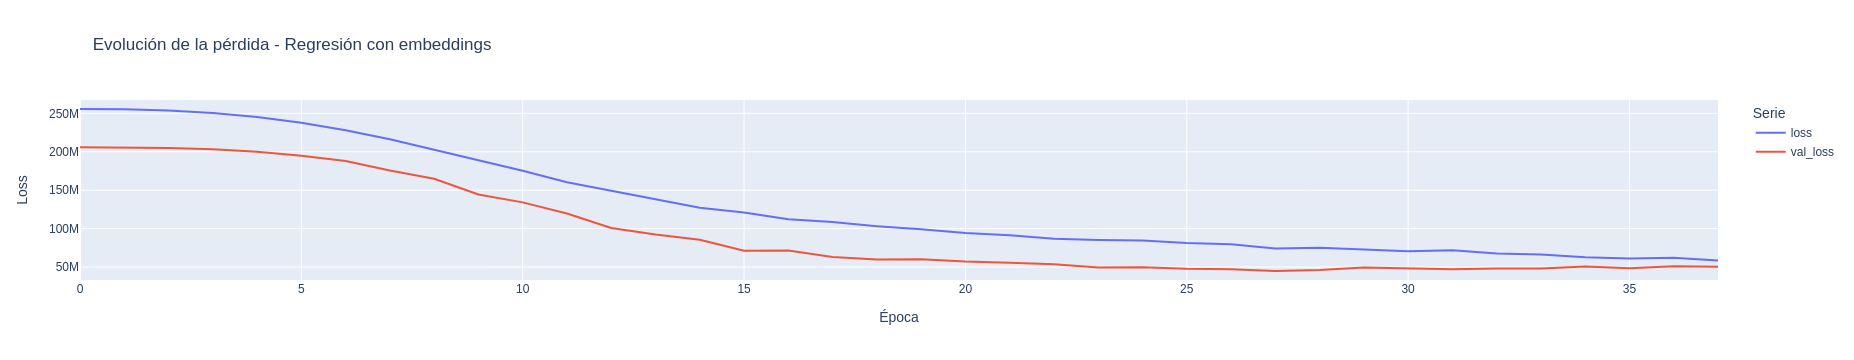

In [85]:
hist_reg = pd.DataFrame(history_emb.history)

fig = px.line(
    hist_reg,
    y=["loss", "val_loss"],
    title="Evolución de la pérdida - Regresión con embeddings",
    labels={"index": "Época", "value": "Loss", "variable": "Serie"}
)

fig.show()

### Evolución de RMSE

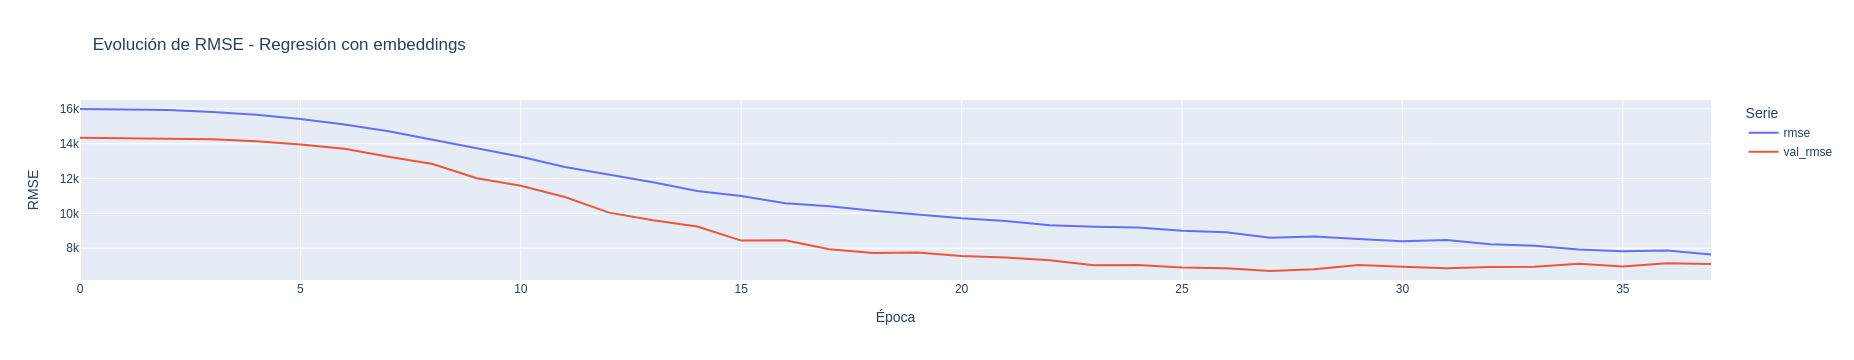

In [86]:
fig = px.line(
    hist_reg,
    y=["rmse", "val_rmse"],
    title="Evolución de RMSE - Regresión con embeddings",
    labels={"index": "Época", "value": "RMSE", "variable": "Serie"}
)

fig.show()

* La pérdida y el RMSE disminuyen de forma consistente a lo largo de las épocas, lo que indica que el modelo logra aprender patrones relevantes en los datos.
* La curva de validación mantiene una tendencia similar a la de entrenamiento, por lo que no se observa un sobreajuste evidente.

### Inputs finales

In [87]:
val_inputs_final = {
    "continuas": X_cont_val_df.values
}

for col in discretas:
    val_inputs_final[col] = X_cat_val_df[col].values

### Predicción de PAY_AMT1

In [90]:
y_hat_val_reg = modelo_emb.predict(val_inputs_final).ravel()

y_hat_val_reg = np.clip(
    y_hat_val_reg,
    a_min=0,
    a_max=None
)

y_hat_val_reg[:10]

 46/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

E0000 00:00:1779417783.167673   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_22}}


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


array([ 3300.5132, 10834.846 ,  6162.5195,  3917.4841,  4685.329 ,
        3654.0874, 19477.908 ,  3104.9614,  3771.3003, 10191.58  ],
      dtype=float32)

### Guardar predicciones

In [91]:
pred_regresion = guardar_predicciones(
    account_ids=val_ids_reg,
    y_hat=y_hat_val_reg,
    nombre_archivo="OrozpeFriasErickAdrian_PAYAMT1.csv",
    output_dir="outputs"
)

pred_regresion.head()

Predicciones guardadas en: outputs/OrozpeFriasErickAdrian_PAYAMT1.csv
(3750, 2)


,ACCOUNT_ID,y_hat
0,5336,"3,300.51"
1,5678,"10,834.85"
2,7675,"6,162.52"
3,3985,"3,917.48"
4,4657,"4,685.33"


In [94]:
pred_regresion.isna().sum()

ACCOUNT_ID    0
y_hat         0
dtype: int64

### Guardar modelo de regresión

In [95]:
guardar_modelo_keras(
    modelo=modelo_emb,
    nombre_modelo="regression_embeddings_PAYAMT1",
    output_dir="models"
)

Modelo guardado en: models/regression_embeddings_PAYAMT1.keras


PosixPath('models/regression_embeddings_PAYAMT1.keras')

### Guardar preprocesador y encoder

In [96]:
guardar_objeto_joblib(
    objeto=preprocessor_scaling,
    nombre_objeto="regression_preprocessor_scaling",
    output_dir="models"
)

guardar_objeto_joblib(
    objeto=encoder_cat,
    nombre_objeto="regression_encoder_cat",
    output_dir="models"
)

Objeto guardado en: models/regression_preprocessor_scaling.joblib
Objeto guardado en: models/regression_encoder_cat.joblib


PosixPath('models/regression_encoder_cat.joblib')

# Modelo de Clasificación

In [101]:
target_class = "default.payment.next.month"
id_col = "ACCOUNT_ID"

df_train_class = train_default.copy()
df_val_class = val_default.copy()

print("Train clasificación:", df_train_class.shape)
print("Validación clasificación:", df_val_class.shape)

Train clasificación: (5625, 25)
Validación clasificación: (1875, 24)


In [102]:
df_resumen_train_default = regresion.resumen_campos(df_train_class)

df_resumen_train_default.style.background_gradient(
    subset=["porcentaje_nulos", "valores_unicos"],
    cmap="Blues"
)

,campo,descripcion,clasificacion,porcentaje_nulos,tipo_dato,valores_unicos
0,ACCOUNT_ID,Identificador único de cada cliente.,id,0.000000,int64,5625
1,LIMIT_BAL,Monto de la línea de crédito otorgada al cliente.,continua,0.000000,float64,70
2,SEX,"Género del cliente: 1 = masculino, 2 = femenino.",discreta,0.000000,int64,2
3,EDUCATION,"Nivel educativo: 1 = preparatoria, 2 = universidad, 3 = secundaria, 4 = otros, 5 = desconocido, 6 = desconocido, 0 = nulo.",discreta,0.000000,int64,7
4,MARRIAGE,"Estado marital: 1 = casado, 2 = soltero, 3 = otros, 0 = nulo.",discreta,0.000000,int64,4
5,AGE,Edad del cliente en años.,continua,0.000000,int64,53
6,PAY_0,Estado de pago en septiembre de 2005.,discreta,0.000000,int64,11
7,PAY_2,Estado de pago en agosto de 2005.,discreta,0.000000,int64,10
8,PAY_3,Estado de pago en julio de 2005.,discreta,0.000000,int64,10
9,PAY_4,Estado de pago en junio de 2005.,discreta,0.000000,int64,10


In [103]:
df_resumen_train_default["clasificacion"] = df_resumen_train_default["campo"].map(
    lambda x: "id" if x == id_col
    else "target" if x == target_class
    else "discreta" if x in ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    else "continua"
)

## EDA

In [104]:
eda_classif = eda_class(
    df=df_train_class,
    resumen_campos=df_resumen_train_default,
    target=target_class,
    id_col=id_col,
    output_dir="img"
)

eda_classif.obtener_columnas("continua"), eda_classif.obtener_columnas("discreta")

(['LIMIT_BAL',
  'AGE',
  'BILL_AMT1',
  'BILL_AMT2',
  'BILL_AMT3',
  'BILL_AMT4',
  'BILL_AMT5',
  'BILL_AMT6',
  'PAY_AMT1',
  'PAY_AMT2',
  'PAY_AMT3',
  'PAY_AMT4',
  'PAY_AMT5',
  'PAY_AMT6'],
 ['SEX',
  'EDUCATION',
  'MARRIAGE',
  'PAY_0',
  'PAY_2',
  'PAY_3',
  'PAY_4',
  'PAY_5',
  'PAY_6'])

In [105]:
continuas_class = eda_classif.obtener_columnas("continua")
discretas_class = eda_classif.obtener_columnas("discreta")

continuas_class = [col for col in continuas_class if col != target_class]
discretas_class = [col for col in discretas_class if col != target_class]

print("Continuas clasificación:", continuas_class)
print("Discretas clasificación:", discretas_class)

Continuas clasificación: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Discretas clasificación: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [106]:
X_train_class_raw = df_train_class[continuas_class + discretas_class].copy()
y_train_class = df_train_class[target_class].astype("int32").copy()

X_val_class_raw = df_val_class[continuas_class + discretas_class].copy()
val_ids_class = df_val_class[id_col].copy()

print("X_train_class_raw:", X_train_class_raw.shape)
print("y_train_class:", y_train_class.shape)
print("X_val_class_raw:", X_val_class_raw.shape)
print("val_ids_class:", val_ids_class.shape)

X_train_class_raw: (5625, 23)
y_train_class: (5625,)
X_val_class_raw: (1875, 23)
val_ids_class: (1875,)


In [107]:
dashboard_classif = eda_dashboard_class(eda_classif)
dashboard_classif.mostrar()

## Outliers

In [108]:
eda_classif.detectar_outliers_iqr().sort_values(by="variable")

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,42.00,14.00,7.00,63.00,30,0.53
2,BILL_AMT1,"3,730.00","68,835.00","65,105.00","-93,927.50","166,492.50",446,7.93
3,BILL_AMT2,"3,297.00","65,430.00","62,133.00","-89,902.50","158,629.50",446,7.93
4,BILL_AMT3,"2,960.00","60,949.00","57,989.00","-84,023.50","147,932.50",463,8.23
5,BILL_AMT4,"2,482.00","55,310.00","52,828.00","-76,760.00","134,552.00",488,8.68
6,BILL_AMT5,"2,037.00","50,841.00","48,804.00","-71,169.00","124,047.00",527,9.37
7,BILL_AMT6,"1,487.00","49,351.00","47,864.00","-70,309.00","121,147.00",528,9.39
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-235,000.00","525,000.00",31,0.55
8,PAY_AMT1,"1,000.00","5,109.00","4,109.00","-5,163.50","11,272.50",530,9.42
9,PAY_AMT2,"1,000.00","5,000.00","4,000.00","-5,000.00","11,000.00",540,9.60


In [109]:
eda_classif.detectar_outliers_iqr(factor=3.0).sort_values(by="variable")

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
1,AGE,28.00,42.00,14.00,-14.00,84.00,0,0.00
2,BILL_AMT1,"3,730.00","68,835.00","65,105.00","-191,585.00","264,150.00",134,2.38
3,BILL_AMT2,"3,297.00","65,430.00","62,133.00","-183,102.00","251,829.00",143,2.54
4,BILL_AMT3,"2,960.00","60,949.00","57,989.00","-171,007.00","234,916.00",158,2.81
5,BILL_AMT4,"2,482.00","55,310.00","52,828.00","-156,002.00","213,794.00",163,2.90
6,BILL_AMT5,"2,037.00","50,841.00","48,804.00","-144,375.00","197,253.00",179,3.18
7,BILL_AMT6,"1,487.00","49,351.00","47,864.00","-142,105.00","192,943.00",188,3.34
0,LIMIT_BAL,"50,000.00","240,000.00","190,000.00","-520,000.00","810,000.00",1,0.02
8,PAY_AMT1,"1,000.00","5,109.00","4,109.00","-11,327.00","17,436.00",316,5.62
9,PAY_AMT2,"1,000.00","5,000.00","4,000.00","-11,000.00","17,000.00",331,5.88


In [112]:
outliers_if_class = eda_classif.detectar_outliers_isolation_forest(
    contamination=0.01,
    random_state=SEED
)

outliers_if_class["es_outlier"].mean() * 100

np.float64(1.0133333333333332)

In [113]:
df_outliers_class = df_train_class.copy()
df_outliers_class["es_outlier_if"] = outliers_if_class["es_outlier"].values

resumen_default_outliers = (
    df_outliers_class
    .groupby("es_outlier_if")[target_class]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "n_registros",
        "mean": "tasa_default"
    })
)

resumen_default_outliers

,n_registros,tasa_default
es_outlier_if,,
False,5568,0.22
True,57,0.21


### Decisión sobre valores atípicos en clasificación

* La revisión univariada mediante IQR mostró presencia de valores extremos principalmente en variables monetarias (`BILL_AMT*` y `PAY_AMT*`), comportamiento esperado por la naturaleza financiera de los datos.

* Con un criterio más estricto (`factor=3.0`), la proporción de valores atípicos disminuye considerablemente, lo que sugiere que una parte importante de los valores detectados con `factor=1.5` corresponde a colas naturales de la distribución.

* En la revisión multivariada con Isolation Forest, usando `contamination=0.03`, los registros atípicos presentan una tasa de default aproximada de 0.16, menor que la observada en el resto de registros.

* Al reducir la contaminación a `0.01`, la tasa de default de los atípicos se aproxima a la tasa general, sin mostrar una mejora clara que justifique su eliminación.

* Dado que los valores atípicos no presentan una concentración significativamente mayor de incumplimiento, no se eliminarán registros en el modelo de clasificación.

* Para conservar la información de perfiles financieros extremos sin afectar de forma excesiva el escalamiento, se utilizará `RobustScaler` en variables continuas y embeddings para variables discretas.

## Escalado (variables continuas)

In [114]:
preprocessor_scaling_class = ColumnTransformer(
    transformers=[
        ("continuas_robust", RobustScaler(), continuas_class),
        ("discretas_passthrough", "passthrough", discretas_class)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_class_scaled_array = preprocessor_scaling_class.fit_transform(X_train_class_raw)
X_val_class_scaled_array = preprocessor_scaling_class.transform(X_val_class_raw)

X_train_class_scaled = pd.DataFrame(
    X_train_class_scaled_array,
    columns=preprocessor_scaling_class.get_feature_names_out(),
    index=X_train_class_raw.index
)

X_val_class_scaled = pd.DataFrame(
    X_val_class_scaled_array,
    columns=preprocessor_scaling_class.get_feature_names_out(),
    index=X_val_class_raw.index
)

X_train_class_scaled.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,0.32,-0.43,0.55,0.65,-0.22,-0.19,-0.21,-0.22,0.47,0.23,0.29,-0.42,-0.16,-0.41,2.00,1.00,2.00,0.00,0.00,0.00,0.00,2.00,2.00
1,0.21,-0.29,2.33,2.11,1.31,1.28,1.22,0.84,4.83,0.48,0.05,0.89,0.35,0.38,1.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.42,-0.21,-0.35,-0.34,-0.35,-0.37,-0.38,-0.37,-0.53,-0.52,-0.43,-0.42,-0.29,-0.41,2.00,1.00,2.00,-1.00,-1.00,-2.00,-2.00,-2.00,-1.00
3,-0.47,-0.57,0.41,0.47,0.45,0.15,0.20,0.23,-0.04,-0.02,-0.19,-0.03,-0.03,0.12,1.00,2.00,2.00,-1.00,0.00,0.00,0.00,0.00,0.00
4,0.53,-0.29,-0.30,-0.34,-0.27,-0.34,-0.23,-0.37,-0.53,0.64,-0.06,1.50,-0.42,-0.41,2.00,1.00,2.00,-1.00,-1.00,-1.00,-1.00,-1.00,0.00


## Embeddings 

In [115]:
encoder_cat_class = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_cat_train_class_encoded = encoder_cat_class.fit_transform(
    X_train_class_raw[discretas_class]
)

X_cat_val_class_encoded = encoder_cat_class.transform(
    X_val_class_raw[discretas_class]
)

X_cat_train_class_encoded = X_cat_train_class_encoded.astype("int32") + 1
X_cat_val_class_encoded = X_cat_val_class_encoded.astype("int32") + 1

In [116]:
X_cont_train_class_df = X_train_class_scaled[continuas_class].astype("float32").copy()
X_cont_val_class_df = X_val_class_scaled[continuas_class].astype("float32").copy()

X_cat_train_class_df = pd.DataFrame(
    X_cat_train_class_encoded,
    columns=discretas_class,
    index=X_train_class_scaled.index
).astype("int32")

X_cat_val_class_df = pd.DataFrame(
    X_cat_val_class_encoded,
    columns=discretas_class,
    index=X_val_class_scaled.index
).astype("int32")

print("X_cont_train_class_df:", X_cont_train_class_df.shape)
print("X_cat_train_class_df:", X_cat_train_class_df.shape)
print("X_cont_val_class_df:", X_cont_val_class_df.shape)
print("X_cat_val_class_df:", X_cat_val_class_df.shape)

X_cont_train_class_df: (5625, 14)
X_cat_train_class_df: (5625, 9)
X_cont_val_class_df: (1875, 14)
X_cat_val_class_df: (1875, 9)


In [117]:
cardinalidades_class = {}

for i, col in enumerate(discretas_class):
    n_categorias = len(encoder_cat_class.categories_[i])
    cardinalidades_class[col] = n_categorias + 1

cardinalidades_class

{'SEX': 3,
 'EDUCATION': 8,
 'MARRIAGE': 5,
 'PAY_0': 12,
 'PAY_2': 11,
 'PAY_3': 11,
 'PAY_4': 11,
 'PAY_5': 11,
 'PAY_6': 11}

## Modelo

In [118]:
def crear_modelo_clasificacion_embeddings(
    n_continuas,
    cardinalidades,
    embedding_dim_default=4
):
    input_cont = layers.Input(
        shape=(n_continuas,),
        name="continuas"
    )

    inputs = [input_cont]
    embeddings = []

    for col, cardinalidad in cardinalidades.items():
        input_cat = layers.Input(
            shape=(1,),
            name=col
        )

        emb_dim = min(embedding_dim_default, max(2, cardinalidad // 2))

        emb = layers.Embedding(
            input_dim=cardinalidad,
            output_dim=emb_dim,
            name=f"emb_{col}"
        )(input_cat)

        emb = layers.Flatten(name=f"flat_{col}")(emb)

        inputs.append(input_cat)
        embeddings.append(emb)

    x = layers.Concatenate(name="concat_features")(
        [input_cont] + embeddings
    )

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(32, activation="relu")(x)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="default_pred"
    )(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [119]:
modelo_class = crear_modelo_clasificacion_embeddings(
    n_continuas=len(continuas_class),
    cardinalidades=cardinalidades_class,
    embedding_dim_default=4
)

modelo_class.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ SEX (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EDUCATION           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MARRIAGE            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_0 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_2 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_3 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_4 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_5 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PAY_6 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_SEX (Embedding) │ (None, 1, 2)      │          6 │ SEX[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_EDUCATION       │ (None, 1, 4)      │         32 │ EDUCATION[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_MARRIAGE        │ (None, 1, 2)      │         10 │ MARRIAGE[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_0           │ (None, 1, 4)      │         48 │ PAY_0[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_2           │ (None, 1, 4)      │         44 │ PAY_2[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_3           │ (None, 1, 4)      │         44 │ PAY_3[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_4           │ (None, 1, 4)      │         44 │ PAY_4[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_5           │ (None, 1, 4)      │         44 │ PAY_5[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PAY_6           │ (None, 1, 4)      │         44 │ PAY_6[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuas           │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 17,469 (68.24 KB)

 Trainable params: 17,085 (66.74 KB)

 Non-trainable params: 384 (1.50 KB)

### Split

In [120]:
idx_train_class, idx_eval_class = train_test_split(
    X_cont_train_class_df.index,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_class
)

print("Train interno clasificación:", len(idx_train_class))
print("Evaluación interna clasificación:", len(idx_eval_class))

print("\nDistribución train:")
print(y_train_class.loc[idx_train_class].value_counts(normalize=True))

print("\nDistribución evaluación:")
print(y_train_class.loc[idx_eval_class].value_counts(normalize=True))

Train interno clasificación: 4500
Evaluación interna clasificación: 1125

Distribución train:
default.payment.next.month
0   0.78
1   0.22
Name: proportion, dtype: float64

Distribución evaluación:
default.payment.next.month
0   0.78
1   0.22
Name: proportion, dtype: float64


### Inputs

In [121]:
train_inputs_class_model = {
    "continuas": X_cont_train_class_df.loc[idx_train_class].values
}

eval_inputs_class_model = {
    "continuas": X_cont_train_class_df.loc[idx_eval_class].values
}

for col in discretas_class:
    train_inputs_class_model[col] = X_cat_train_class_df.loc[idx_train_class, col].values
    eval_inputs_class_model[col] = X_cat_train_class_df.loc[idx_eval_class, col].values

y_train_class_model = y_train_class.loc[idx_train_class].astype("int32").values
y_eval_class_model = y_train_class.loc[idx_eval_class].astype("int32").values

print("y_train_class_model:", y_train_class_model.shape)
print("y_eval_class_model:", y_eval_class_model.shape)

y_train_class_model: (4500,)
y_eval_class_model: (1125,)


### Entrenamiento

In [129]:
early_stop_class = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_class = modelo_class.fit(
    train_inputs_class_model,
    y_train_class_model,
    validation_data=(eval_inputs_class_model, y_eval_class_model),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop_class],
    verbose=1
)

Epoch 1/100


E0000 00:00:1779421026.971537   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_24}}


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6962 - auc: 0.5607 - loss: 0.6244 - precision: 0.2668 - recall: 0.2114 - val_accuracy: 0.7778 - val_auc: 0.6590 - val_loss: 0.5537 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7733 - auc: 0.6328 - loss: 0.5241 - precision: 0.4304 - recall: 0.0681 - val_accuracy: 0.7787 - val_auc: 0.7126 - val_loss: 0.5203 - val_precision: 1.0000 - val_recall: 0.0040
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7847 - auc: 0.6866 - loss: 0.4988 - precision: 0.5498 - recall: 0.1603 - val_accuracy: 0.7796 - val_auc: 0.7506 - val_loss: 0.4899 - val_precision: 0.7500 - val_recall: 0.0120
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7964 - auc: 0.7266 - loss: 0.4746 - precision: 0.6005 - recall: 0.2455 - val_accuracy: 0.7849 - val_auc: 0.7645 - val_loss: 0.4708 - val_precision: 0.7857 - val_recall: 0.0440
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━

### Evaluación de desempeño

In [130]:
y_proba_eval_class = modelo_class.predict(eval_inputs_class_model).ravel()

metricas_class_050 = evaluar_clasificacion(
    y_true=y_eval_class_model,
    y_proba=y_proba_eval_class,
    threshold=0.50,
    nombre_modelo="red_embeddings_clasificacion"
)

metricas_class_050

21/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

E0000 00:00:1779421080.539067   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_23}}


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


,modelo,threshold,accuracy,precision,recall,f1_score,roc_auc
0,red_embeddings_clasificacion,0.50,0.82,0.70,0.32,0.44,0.79


In [131]:
y_pred_eval_class = (y_proba_eval_class >= 0.50).astype(int)

print(confusion_matrix(y_eval_class_model, y_pred_eval_class))
print(classification_report(y_eval_class_model, y_pred_eval_class, zero_division=0))

[[841  34]
 [170  80]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       875
           1       0.70      0.32      0.44       250

    accuracy                           0.82      1125
   macro avg       0.77      0.64      0.67      1125
weighted avg       0.80      0.82      0.79      1125



### Ajuste del umbral de clasificación

En modelos de clasificación binaria, la salida de la red neuronal corresponde a una probabilidad estimada de pertenecer a la clase positiva. En este caso, la clase positiva representa el incumplimiento de pago (`default.payment.next.month = 1`).

Inicialmente se utiliza un umbral estándar de 0.50, donde probabilidades mayores o iguales a dicho valor se clasifican como incumplimiento. Sin embargo, debido al desbalance natural entre clientes que incumplen y clientes que no incumplen, este umbral puede no ser el más adecuado para maximizar la detección de la clase objetivo.

Por ello, se evalúan distintos valores de threshold con el objetivo de encontrar un mejor balance entre precisión, recall y F1-score. En este problema, resulta especialmente importante mejorar la capacidad del modelo para identificar clientes que podrían incurrir en incumplimiento, ya que un falso negativo implica clasificar como no riesgoso a un cliente que realmente incumple.

Bajo este enfoque, se prioriza un mayor recall de la clase positiva, aun cuando esto pueda reducir parcialmente la precisión. Esta decisión es razonable en un contexto de riesgo crediticio, donde omitir clientes con posible incumplimiento puede tener un costo operativo o financiero mayor que marcar algunos clientes sanos como potencialmente riesgosos.

#### Búsqueda del umbral óptimo mediante F1-score

In [132]:
thresholds = np.arange(0.10, 0.91, 0.01)

resultados_threshold = []

for threshold in thresholds:
    y_pred_tmp = (y_proba_eval_class >= threshold).astype(int)

    resultados_threshold.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval_class_model, y_pred_tmp),
        "precision": precision_score(y_eval_class_model, y_pred_tmp, zero_division=0),
        "recall": recall_score(y_eval_class_model, y_pred_tmp, zero_division=0),
        "f1_score": f1_score(y_eval_class_model, y_pred_tmp, zero_division=0)
    })

df_thresholds = pd.DataFrame(resultados_threshold)

df_thresholds.sort_values("f1_score", ascending=False).head(10)

,threshold,accuracy,precision,recall,f1_score
14,0.24,0.77,0.48,0.65,0.55
15,0.25,0.77,0.49,0.63,0.55
19,0.29,0.79,0.54,0.57,0.55
17,0.27,0.79,0.52,0.59,0.55
18,0.28,0.79,0.52,0.57,0.55
16,0.26,0.77,0.49,0.60,0.54
13,0.23,0.75,0.46,0.66,0.54
22,0.32,0.80,0.56,0.52,0.54
12,0.22,0.74,0.45,0.68,0.54
20,0.30,0.79,0.53,0.54,0.54


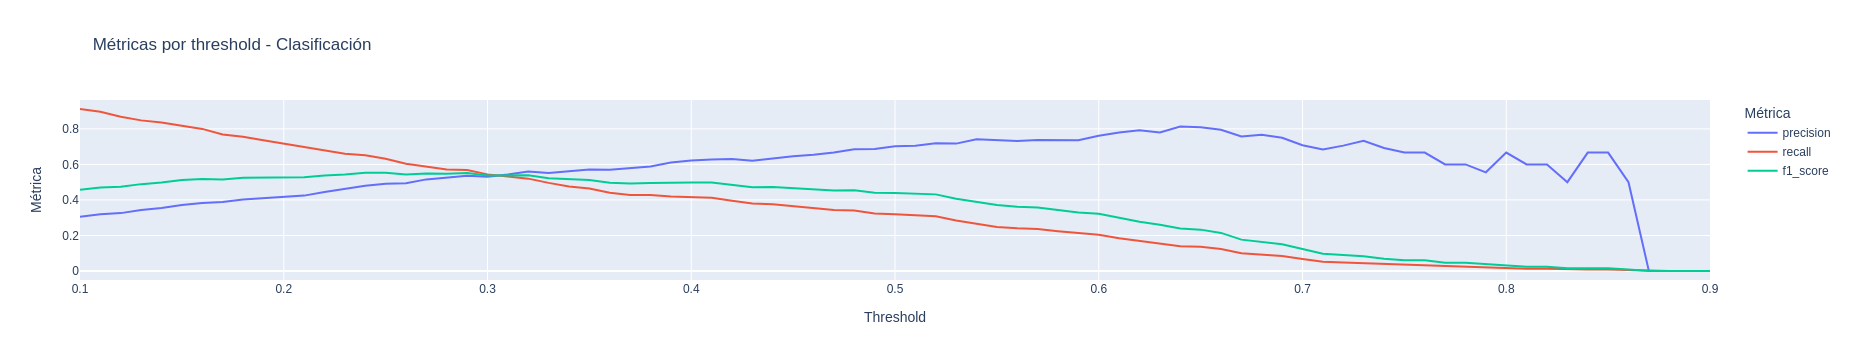

In [133]:
fig = px.line(
    df_thresholds,
    x="threshold",
    y=["precision", "recall", "f1_score"],
    title="Métricas por threshold - Clasificación",
    labels={
        "threshold": "Threshold",
        "value": "Métrica",
        "variable": "Métrica"
    }
)

fig.show()

In [134]:
best_threshold_class = (
    df_thresholds
    .sort_values("f1_score", ascending=False)
    .iloc[0]["threshold"]
)

best_threshold_class

np.float64(0.23999999999999994)

#### Desempeño con threshold ajustado

In [135]:
metricas_class_best = evaluar_clasificacion(
    y_true=y_eval_class_model,
    y_proba=y_proba_eval_class,
    threshold=best_threshold_class,
    nombre_modelo="red_embeddings_clasificacion_best_threshold"
)

metricas_class_best

,modelo,threshold,accuracy,precision,recall,f1_score,roc_auc
0,red_embeddings_clasificacion_best_threshold,0.24,0.77,0.48,0.65,0.55,0.79


La matriz de confusión se interpreta bajo la estructura:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

donde:

- `TN`: clientes correctamente clasificados como no incumplidos.
- `FP`: clientes clasificados como incumplidos, aunque realmente no incumplieron.
- `FN`: clientes clasificados como no incumplidos, aunque realmente sí incumplieron.
- `TP`: clientes correctamente clasificados como incumplidos.

En este caso, el error más relevante es el falso negativo (`FN`), ya que representa clientes que sí incumplen pero que el modelo clasifica como no incumplidos.

In [136]:
y_pred_eval_best = (y_proba_eval_class >= best_threshold_class).astype(int)

print(confusion_matrix(y_eval_class_model, y_pred_eval_best))
print(classification_report(y_eval_class_model, y_pred_eval_best, zero_division=0))

[[698 177]
 [ 87 163]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       875
           1       0.48      0.65      0.55       250

    accuracy                           0.77      1125
   macro avg       0.68      0.72      0.70      1125
weighted avg       0.80      0.77      0.78      1125



### Evolución de pérdida

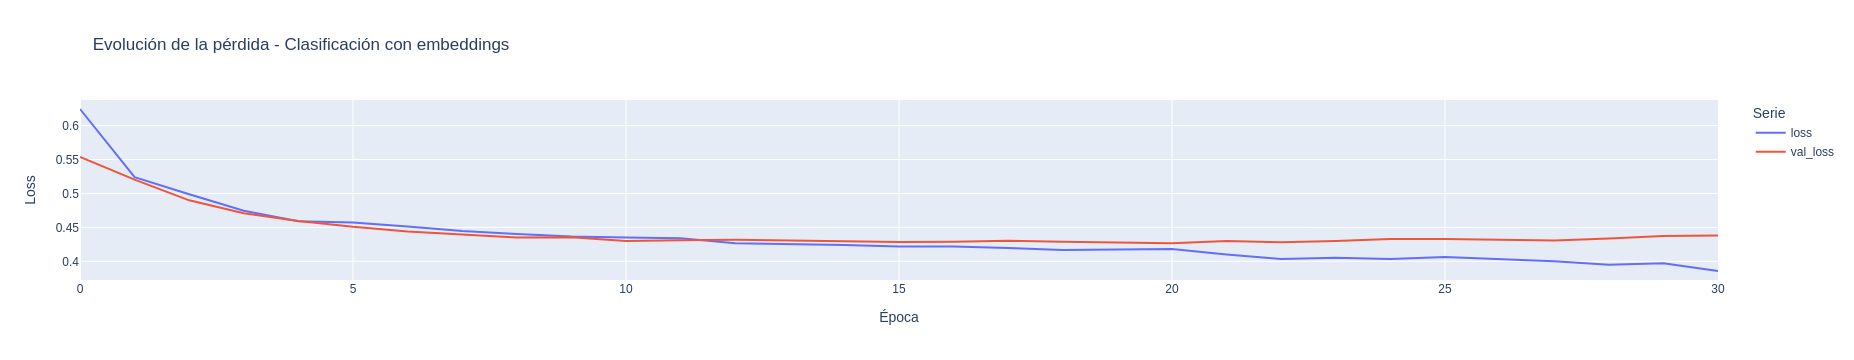

In [137]:
hist_class = pd.DataFrame(history_class.history)

fig = px.line(
    hist_class,
    y=["loss", "val_loss"],
    title="Evolución de la pérdida - Clasificación con embeddings",
    labels={"index": "Época", "value": "Loss", "variable": "Serie"}
)

fig.show()

### Evolución de accuracy

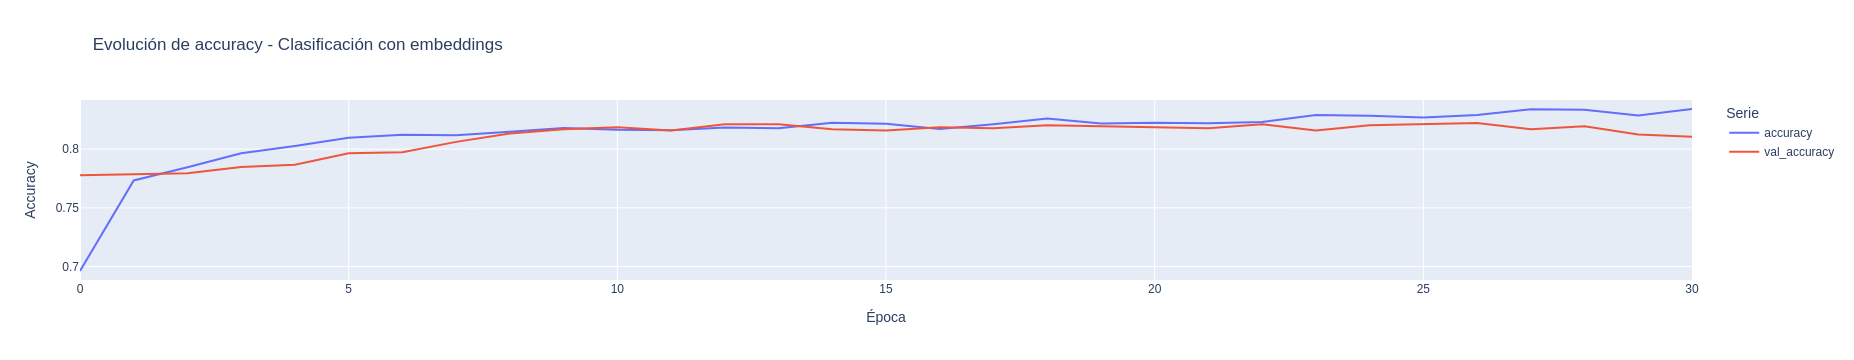

In [138]:
fig = px.line(
    hist_class,
    y=["accuracy", "val_accuracy"],
    title="Evolución de accuracy - Clasificación con embeddings",
    labels={"index": "Época", "value": "Accuracy", "variable": "Serie"}
)

fig.show()

### Evolución de AUC

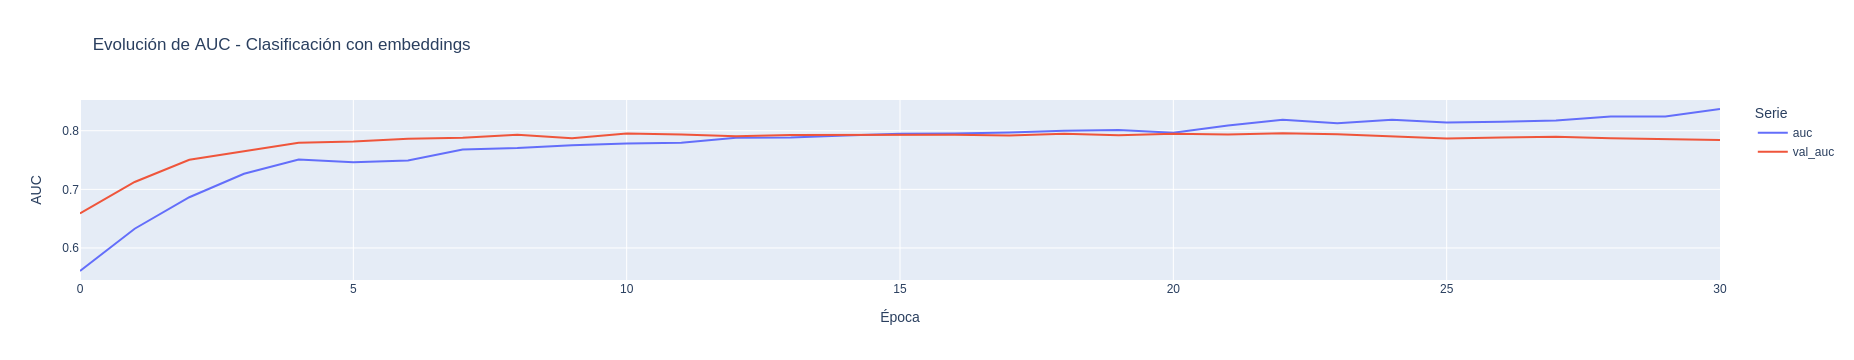

In [139]:
fig = px.line(
    hist_class,
    y=["auc", "val_auc"],
    title="Evolución de AUC - Clasificación con embeddings",
    labels={"index": "Época", "value": "AUC", "variable": "Serie"}
)

fig.show()

### Conclusiones del ajuste de threshold

1. Con el umbral estándar de 0.50, el modelo presenta una buena exactitud general y una precisión alta para la clase de incumplimiento, pero el recall de la clase positiva es bajo.

2. Esto significa que, aunque el modelo es confiable cuando predice incumplimiento, deja fuera una proporción importante de clientes que realmente incumplen.

3. Al evaluar distintos thresholds, se observa que reducir el umbral incrementa el recall de la clase positiva, permitiendo identificar más clientes con riesgo de incumplimiento.

4. El mejor threshold identificado mediante F1-score fue aproximadamente 0.24, con lo cual se obtiene un mejor balance entre precisión y recall.

5. Con el threshold ajustado, la precisión disminuye respecto al umbral 0.50, pero el recall de la clase positiva aumenta de forma importante, lo cual es deseable para este problema.

6. La matriz de confusión confirma que el ajuste reduce los falsos negativos, es decir, disminuye la cantidad de clientes incumplidos que el modelo clasifica incorrectamente como no incumplidos.

7. La evolución de entrenamiento muestra un comportamiento estable: la pérdida disminuye, la exactitud se mantiene consistente y el AUC mejora durante las épocas sin evidencia clara de sobreajuste.

8. En conjunto, el modelo de clasificación con embeddings y threshold ajustado resulta más adecuado para el objetivo del problema, ya que prioriza la detección de posibles incumplimientos sin perder completamente el balance general del desempeño.

### Inputs finales

In [141]:
val_inputs_class_final = {
    "continuas": X_cont_val_class_df.values
}

for col in discretas_class:
    val_inputs_class_final[col] = X_cat_val_class_df[col].values

### Predicción de default.payment

In [142]:
y_proba_val_class = modelo_class.predict(val_inputs_class_final).ravel()

y_hat_val_class = (
    y_proba_val_class >= best_threshold_class
).astype(int)

pd.Series(y_hat_val_class).value_counts(normalize=True)

54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

E0000 00:00:1779422135.485733   23990 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_23}}


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


0   0.69
1   0.31
Name: proportion, dtype: float64

In [143]:
pred_preview_class = pd.DataFrame({
    "ACCOUNT_ID": val_ids_class,
    "prob_default": y_proba_val_class,
    "y_hat": y_hat_val_class
})

pred_preview_class.head()

,ACCOUNT_ID,prob_default,y_hat
0,14883,0.08,0
1,1582,0.10,0
2,12784,0.09,0
3,8691,0.07,0
4,27398,0.63,1


### Guardar predicciones

In [144]:
pred_clasificacion = guardar_predicciones(
    account_ids=val_ids_class,
    y_hat=y_hat_val_class,
    nombre_archivo="OrozpeFriasErickAdrian_DefaultPayment.csv",
    output_dir="outputs"
)

pred_clasificacion.head()

Predicciones guardadas en: outputs/OrozpeFriasErickAdrian_DefaultPayment.csv
(1875, 2)


,ACCOUNT_ID,y_hat
0,14883,0
1,1582,0
2,12784,0
3,8691,0
4,27398,1


In [145]:
print(pred_clasificacion.shape)
print(pred_clasificacion.columns.tolist())
print(pred_clasificacion.isna().sum())
print(pred_clasificacion["y_hat"].value_counts())

(1875, 2)
['ACCOUNT_ID', 'y_hat']
ACCOUNT_ID    0
y_hat         0
dtype: int64
y_hat
0    1303
1     572
Name: count, dtype: int64


### Guardar modelo de clasificación

In [146]:
guardar_modelo_keras(
    modelo=modelo_class,
    nombre_modelo="classification_embeddings_DefaultPayment",
    output_dir="models"
)

Modelo guardado en: models/classification_embeddings_DefaultPayment.keras


PosixPath('models/classification_embeddings_DefaultPayment.keras')

### Guardar preprocesador y encoder

In [147]:
guardar_objeto_joblib(
    objeto=preprocessor_scaling_class,
    nombre_objeto="classification_preprocessor_scaling",
    output_dir="models"
)

guardar_objeto_joblib(
    objeto=encoder_cat_class,
    nombre_objeto="classification_encoder_cat",
    output_dir="models"
)

Objeto guardado en: models/classification_preprocessor_scaling.joblib
Objeto guardado en: models/classification_encoder_cat.joblib


PosixPath('models/classification_encoder_cat.joblib')

### Guardar threshold

In [148]:
threshold_class_path = Path("models") / "classification_best_threshold.txt"

with open(threshold_class_path, "w") as f:
    f.write(str(best_threshold_class))

print(f"Threshold guardado en: {threshold_class_path}")
print("Best threshold:", best_threshold_class)

Threshold guardado en: models/classification_best_threshold.txt
Best threshold: 0.23999999999999994


# Validaciones

## Validación de archivos generados

In [149]:
print("Archivos en outputs:")
for file in Path("outputs").glob("*.csv"):
    print(file)

print("\nArchivos en models:")
for file in Path("models").glob("*"):
    print(file)

Archivos en outputs:
outputs/OrozpeFriasErickAdrian_DefaultPayment.csv
outputs/OrozpeFriasErickAdrian_PAYAMT1.csv

Archivos en models:
models/regression_preprocessor_scaling.joblib
models/regression_embeddings_PAYAMT1.keras
models/regression_encoder_cat.joblib
models/classification_preprocessor_scaling.joblib
models/classification_embeddings_DefaultPayment.keras
models/classification_best_threshold.txt
models/classification_encoder_cat.joblib


## Validación de predicciones

In [150]:
archivo_reg = Path("outputs") / "OrozpeFriasErickAdrian_PAYAMT1.csv"
archivo_class = Path("outputs") / "OrozpeFriasErickAdrian_DefaultPayment.csv"

df_reg_final = pd.read_csv(archivo_reg)
df_class_final = pd.read_csv(archivo_class)

print("Regresión:")
print(df_reg_final.shape)
print(df_reg_final.columns.tolist())
display(df_reg_final.head())

print("\nClasificación:")
print(df_class_final.shape)
print(df_class_final.columns.tolist())
display(df_class_final.head())

Regresión:
(3750, 2)
['ACCOUNT_ID', 'y_hat']


,ACCOUNT_ID,y_hat
0,5336,"3,300.51"
1,5678,"10,834.85"
2,7675,"6,162.52"
3,3985,"3,917.48"
4,4657,"4,685.33"



Clasificación:
(1875, 2)
['ACCOUNT_ID', 'y_hat']


,ACCOUNT_ID,y_hat
0,14883,0
1,1582,0
2,12784,0
3,8691,0
4,27398,1


## Validación de formato en predicciones

In [151]:
assert df_reg_final.columns.tolist() == ["ACCOUNT_ID", "y_hat"]
assert df_class_final.columns.tolist() == ["ACCOUNT_ID", "y_hat"]

print("Estructura de entregables correcta.")

Estructura de entregables correcta.


# Bitácora de IA

Durante el desarrollo de la práctica se utilizó inteligencia artificial como herramienta de apoyo técnico y metodológico para estructurar el análisis, validar decisiones de modelado y mejorar la organización del notebook.

La IA apoyó principalmente en:

- Construcción de funciones auxiliares para resumen de campos, validación de nulos, identificación de variables continuas y discretas.
- Desarrollo del análisis exploratorio mediante gráficos interactivos con Plotly.
- Implementación de escalamiento para variables continuas mediante `ColumnTransformer`.
- Preparación de variables discretas mediante embeddings para redes neuronales.
- Ajuste del threshold del modelo de clasificación para mejorar la detección de incumplimiento.

Aunque la IA ayudó a acelerar tareas de programación, depuración, redacción e interpretación, todas las decisiones finales sobre limpieza de datos, tratamiento de atípicos, arquitectura de modelos, métricas y conclusiones fueron revisadas y ajustadas manualmente.